# 1. Import Libraries & Load Data

In [1]:
import torch, sys
print(sys.executable)
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA:", torch.version.cuda)
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

c:\Users\Seyoung\Desktop\ML_cf_mentalhealth\Code\.venv\Scripts\python.exe
2.10.0+cu128
CUDA available: True
Torch CUDA: 12.8
NVIDIA GeForce RTX 5080 Laptop GPU


In [ ]:
# Imports needed for modeling
import os
import re
import math
import json
import random
import warnings
import numpy as np
import pandas as pd

from collections import Counter

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

# Text cleaning
import contractions
import emoji

# Modeling and Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    auc
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Sentence embeddings
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.style.use("default")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


In [3]:
from sklearn.pipeline import FeatureUnion

In [4]:
# Load labeled training data and unlabeled test data

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Basic cleanup
train_df["text"] = train_df["text"].fillna("").astype(str)
train_df["status"] = train_df["status"].astype(str)
test_df["text"] = test_df["text"].fillna("").astype(str)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain columns:", list(train_df.columns))
print("Test columns:", list(test_df.columns))

display(train_df.head())
display(test_df.head())

print("\nTraining class distribution:")
display(train_df["status"].value_counts())

Train shape: (41174, 3)
Test shape: (8436, 2)

Train columns: ['id', 'text', 'status']
Test columns: ['id', 'text']


,id,text,status
0,37183,i wish i wa in sydney,Normal
1,10228,being an adult is so fucking lonely. everyone ...,Suicidal
2,18073,"I would assume not, considering I could just f...",Suicidal
3,1576,I just realized that yesterday I haven't eaten...,Normal
4,12577,"Day #1Decided to not kill myself today, and I ...",Suicidal


,id,text
0,37716,be offline
1,17470,"I cannot fucking take this shit anymore, my fa..."
2,7630,I am in a really dark place right now and I ju...
3,9138,Its pointless. Fuck This world Yeah fuck it
4,11713,I have had a rough week or so. I have been thi...



Training class distribution:


status
Normal        16281
Depression    12397
Suicidal       9102
Anxiety        3394
Name: count, dtype: int64

# 2. Text Cleaning

In [ ]:
# Text Cleaning

def clean_text_for_model(text):
    text = str(text)

    # Normalize curly apostrophes and similar variants
    text = text.replace("’", "'").replace("`", "'")

    # Lowercase for consistency
    text = text.lower()

    # Expand contractions: "can't" -> "cannot"
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove mentions like @username
    text = re.sub(r"@\w+", " ", text)

    # Normalize hashtags by removing # but keeping the word
    text = re.sub(r"#(\w+)", r"\1", text)

    # Convert emojis to text descriptions
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Normalize elongated words: "sooooo" -> "soo"
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # Keep letters, digits, spaces, ! and ?
    text = re.sub(r"[^a-z0-9!? ]", " ", text)

    # Collapse repeated whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Apply corrected cleaning to both datasets
train_df["clean_text_model"] = train_df["text"].apply(clean_text_for_model)
test_df["clean_text_model"] = test_df["text"].apply(clean_text_for_model)

display(train_df[["text", "clean_text_model"]].head(10))

,text,clean_text_model
0,i wish i wa in sydney,i wish i wa in sydney
1,being an adult is so fucking lonely. everyone ...,being an adult is so fucking lonely everyone i...
2,"I would assume not, considering I could just f...",i would assume not considering i could just fa...
3,I just realized that yesterday I haven't eaten...,i just realized that yesterday i have not eate...
4,"Day #1Decided to not kill myself today, and I ...",day 1decided to not kill myself today and i am...
5,yakedoshita,yakedoshita
6,17F. I’ve been fantasizing about this night si...,17f i have been fantasizing about this night s...
7,found 2 cockroaches on my bed and one in my cl...,found 2 cockroaches on my bed and one in my cl...
8,I had a moment earlier when I was setting up f...,i had a moment earlier when i was setting up f...
9,the one that stole a small plane?,the one that stole a small plane?


# 3. Validation Split

In [6]:
# Encode labels and create a validation split
# We do not use test.csv for evaluation because it is unlabeled.
# We will:
# - split the labeled training set into train/validation
# - use cross-validation for more rigorous model comparison
# - later retrain the best model on the full training set

label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(train_df["status"])

print("Label mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{cls} -> {i}")

X_text_all = train_df["clean_text_model"].copy()

X_train_text, X_val_text, y_train, y_val, idx_train, idx_val = train_test_split(
    X_text_all,
    y_all,
    train_df.index,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_all
)

# Reset text indices for convenience
X_train_text = X_train_text.reset_index(drop=True)
X_val_text = X_val_text.reset_index(drop=True)

# Also keep raw labels for readable output
y_train_labels = label_encoder.inverse_transform(y_train)
y_val_labels = label_encoder.inverse_transform(y_val)

print("Training split size:", len(X_train_text))
print("Validation split size:", len(X_val_text))

print("\nValidation class distribution:")
print(pd.Series(y_val_labels).value_counts())

Label mapping:
Anxiety -> 0
Depression -> 1
Normal -> 2
Suicidal -> 3
Training split size: 32939
Validation split size: 8235

Validation class distribution:
Normal        3256
Depression    2480
Suicidal      1820
Anxiety        679
Name: count, dtype: int64


## Helper for Evaluation Metrics

In [ ]:
# Helper functions for evaluation

def plot_confusion(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()


def suicidal_pr_auc_from_probs(y_true, y_prob, class_names):
    """
    Compute one-vs-rest PR-AUC for the Suicidal class.

    Parameters
    - y_true : shape of an array (n_samples,)
        Labels encoded as integers
    - y_prob : array-like of shape (n_samples, n_classes)
        Predicted probabilities for each class
    - class_names : list-like
        Names of classes in encoder order

    Returns dictionary of precision, recall, thresholds, average_precision, and area under PR curve.
    """
    suicidal_index = list(class_names).index("Suicidal")

    # Convert multiclass labels into binary: 1 if suicidal, 0 otherwise
    y_true_binary = (np.array(y_true) == suicidal_index).astype(int)
    suicidal_probs = y_prob[:, suicidal_index]

    precision, recall, thresholds = precision_recall_curve(y_true_binary, suicidal_probs)
    pr_auc = auc(recall, precision)
    ap = average_precision_score(y_true_binary, suicidal_probs)

    return {
        "precision": precision,
        "recall": recall,
        "thresholds": thresholds,
        "pr_auc": pr_auc,
        "average_precision": ap
    }


def plot_pr_curve(pr_dict, title):
    """
    Plot precision-recall curve for suicidal detection.
    """
    plt.figure(figsize=(6, 5))
    plt.plot(pr_dict["recall"], pr_dict["precision"], linewidth=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title}\nPR-AUC = {pr_dict['pr_auc']:.4f}, AP = {pr_dict['average_precision']:.4f}")
    plt.tight_layout()
    plt.show()


def evaluate_classifier(model_name, model, X_train, y_train, X_val, y_val, class_names, has_predict_proba=True):
    """
    Fit a classifier -> evaluate it on validation data -> return metrics
    """
    print("=" * 80)
    print(f"MODEL: {model_name}")
    print("=" * 80)

    # Fit the model on training data
    model.fit(X_train, y_train)

    # Predict validation labels
    y_pred = model.predict(X_val)

    # Overall metrics
    acc = accuracy_score(y_val, y_pred)
    macro_f1 = f1_score(y_val, y_pred, average="macro")
    weighted_f1 = f1_score(y_val, y_pred, average="weighted")
    macro_precision = precision_score(y_val, y_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_val, y_pred, average="macro", zero_division=0)

    print(f"Accuracy:      {acc:.4f}")
    print(f"Macro F1:      {macro_f1:.4f}")
    print(f"Weighted F1:   {weighted_f1:.4f}")
    print(f"Macro Prec.:   {macro_precision:.4f}")
    print(f"Macro Recall:  {macro_recall:.4f}\n")

    print("Classification report:")
    print(classification_report(
        y_val,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    ))

    plot_confusion(
        y_true=y_val,
        y_pred=y_pred,
        class_names=class_names,
        title=f"Confusion Matrix: {model_name}"
    )

    results = {
        "model": model_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall
    }

    # Probability-based evaluation for suicidal detection
    if has_predict_proba:
        y_prob = model.predict_proba(X_val)
        pr_dict = suicidal_pr_auc_from_probs(y_val, y_prob, class_names)

        print(f"Suicidal one-vs-rest PR-AUC: {pr_dict['pr_auc']:.4f}")
        print(f"Suicidal Average Precision:  {pr_dict['average_precision']:.4f}")

        plot_pr_curve(pr_dict, title=f"Suicidal Detection PR Curve: {model_name}")

        results["suicidal_pr_auc"] = pr_dict["pr_auc"]
        results["suicidal_average_precision"] = pr_dict["average_precision"]

    return results

## Helper for CV (K-fold)

In [ ]:
# Cross-validation helper
# we conduct 5-fold stratified cross-validation and return mean/std metrics

def cross_validate_model(model_name, model, X, y):
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    scoring = {
        "accuracy": "accuracy",
        "macro_f1": "f1_macro",
        "weighted_f1": "f1_weighted"
    }

    cv_results = cross_validate(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring,
        n_jobs=None,
        return_train_score=False
    )

    summary = {
        "model": model_name,
        "cv_accuracy_mean": np.mean(cv_results["test_accuracy"]),
        "cv_accuracy_std": np.std(cv_results["test_accuracy"]),
        "cv_macro_f1_mean": np.mean(cv_results["test_macro_f1"]),
        "cv_macro_f1_std": np.std(cv_results["test_macro_f1"]),
        "cv_weighted_f1_mean": np.mean(cv_results["test_weighted_f1"]),
        "cv_weighted_f1_std": np.std(cv_results["test_weighted_f1"]),
    }

    print(f"\nCross-validation summary for {model_name}")
    for k, v in summary.items():
        if k != "model":
            print(f"{k}: {v:.4f}")

    return summary

# 4. TF-IDF Models

## Word TF-IDF + LR

MODEL: TF-IDF + Multinomial Logistic Regression
Accuracy:      0.7864
Macro F1:      0.7632
Weighted F1:   0.7852
Macro Prec.:   0.7553
Macro Recall:  0.7739

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.7071    0.8071    0.7538       679
  Depression     0.7418    0.6685    0.7033      2480
      Normal     0.8989    0.9205    0.9096      3256
    Suicidal     0.6732    0.6995    0.6861      1820

    accuracy                         0.7864      8235
   macro avg     0.7553    0.7739    0.7632      8235
weighted avg     0.7859    0.7864    0.7852      8235



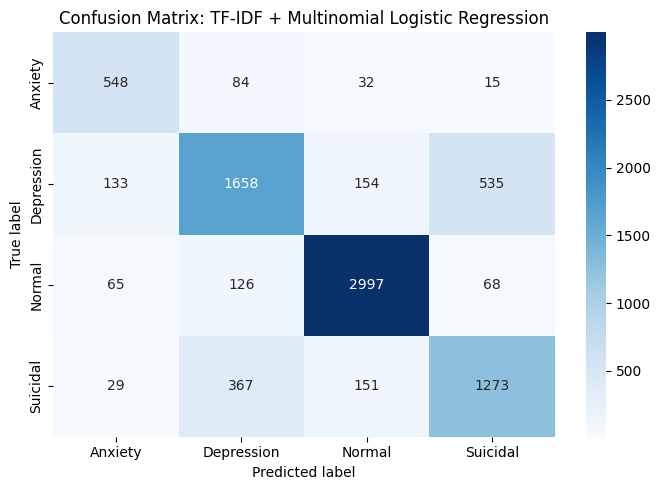

Suicidal one-vs-rest PR-AUC: 0.7166
Suicidal Average Precision:  0.7168


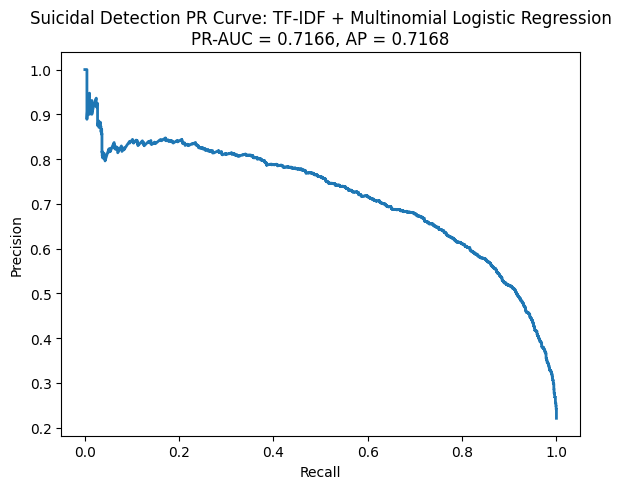


Cross-validation summary for TF-IDF + Multinomial Logistic Regression
cv_accuracy_mean: 0.7879
cv_accuracy_std: 0.0051
cv_macro_f1_mean: 0.7639
cv_macro_f1_std: 0.0053
cv_weighted_f1_mean: 0.7867
cv_weighted_f1_std: 0.0051


In [ ]:
# Model 1 (Baseline): TF-IDF + Multinomial Logistic Regression

# Logistic regression is used as baseline because it is interpretable and fast

tfidf_logreg = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),      # unigrams + bigrams
        min_df=3,                # ignore extremely rare terms
        max_df=0.95,             # ignore very common near-stopword terms
        sublinear_tf=True,       # log-scale term frequency
        strip_accents="unicode"
    )),

    # scikit-learn is already choosing the multiclass behavior automatically,
    # so multiclass argument is unnecessary.
    ("clf", LogisticRegression(
        solver="saga",
        max_iter=3000,
        # Suicidal class is smaller than Normal / Depression
        # Balanced weights reduce bias toward the majority classes
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

res_tfidf_logreg = evaluate_classifier(
    model_name="TF-IDF + Multinomial Logistic Regression",
    model=tfidf_logreg,
    X_train=X_train_text,
    y_train=y_train,
    X_val=X_val_text,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_tfidf_logreg = cross_validate_model(
    model_name="TF-IDF + Multinomial Logistic Regression",
    model=tfidf_logreg,
    X=X_text_all,
    y=y_all
)

## Word TF-IDF + SVM

MODEL: TF-IDF + Calibrated Linear SVM
Accuracy:      0.7925
Macro F1:      0.7674
Weighted F1:   0.7894
Macro Prec.:   0.7859
Macro Recall:  0.7535

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.8437    0.6996    0.7649       679
  Depression     0.7187    0.7242    0.7214      2480
      Normal     0.8807    0.9478    0.9130      3256
    Suicidal     0.7004    0.6423    0.6701      1820

    accuracy                         0.7925      8235
   macro avg     0.7859    0.7535    0.7674      8235
weighted avg     0.7890    0.7925    0.7894      8235



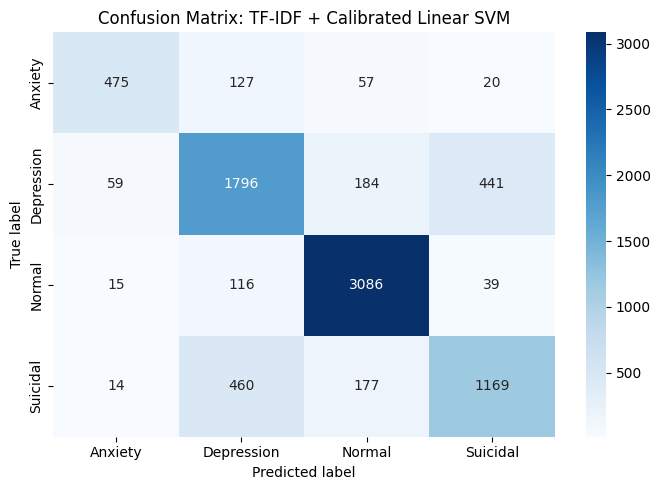

Suicidal one-vs-rest PR-AUC: 0.7232
Suicidal Average Precision:  0.7234


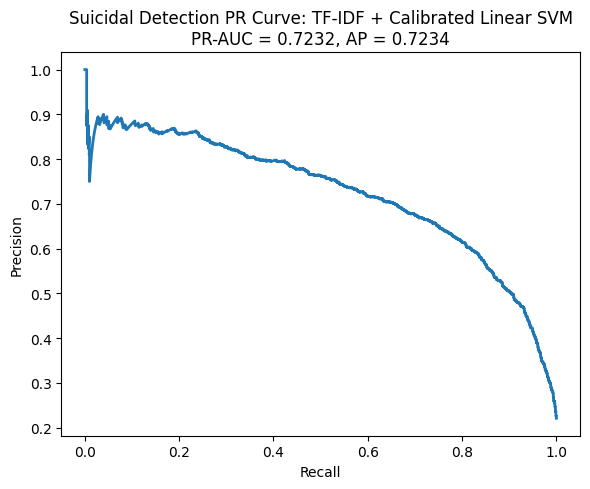


Cross-validation summary for TF-IDF + Calibrated Linear SVM
cv_accuracy_mean: 0.7931
cv_accuracy_std: 0.0031
cv_macro_f1_mean: 0.7672
cv_macro_f1_std: 0.0040
cv_weighted_f1_mean: 0.7900
cv_weighted_f1_std: 0.0031


In [ ]:
# Model 2 (Model Improvement): TF-IDF + Linear SVM

# We use calibrated SVM because:
# - LinearSVC does not output probabilities by default
# - calibration lets us estimate probabilities
# - that allows us to compute PR-AUC for the Suicidal class

base_linear_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        sublinear_tf=True,
        strip_accents="unicode"
    )),
    ("svm", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# Calibrate margins into probabilities using cross-validated calibration
tfidf_svm = CalibratedClassifierCV(
    estimator=base_linear_svm,
    method="sigmoid",
    cv=3
)

res_tfidf_svm = evaluate_classifier(
    model_name="TF-IDF + Calibrated Linear SVM",
    model=tfidf_svm,
    X_train=X_train_text,
    y_train=y_train,
    X_val=X_val_text,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_tfidf_svm = cross_validate_model(
    model_name="TF-IDF + Calibrated Linear SVM",
    model=tfidf_svm,
    X=X_text_all,
    y=y_all
)

## Word TF-IDF + RF

MODEL: TF-IDF + Random Forest
Accuracy:      0.7033
Macro F1:      0.5952
Weighted F1:   0.6802
Macro Prec.:   0.7689
Macro Recall:  0.5767

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.9720    0.2047    0.3382       679
  Depression     0.5856    0.7617    0.6621      2480
      Normal     0.7843    0.9223    0.8477      3256
    Suicidal     0.7338    0.4181    0.5327      1820

    accuracy                         0.7033      8235
   macro avg     0.7689    0.5767    0.5952      8235
weighted avg     0.7288    0.7033    0.6802      8235



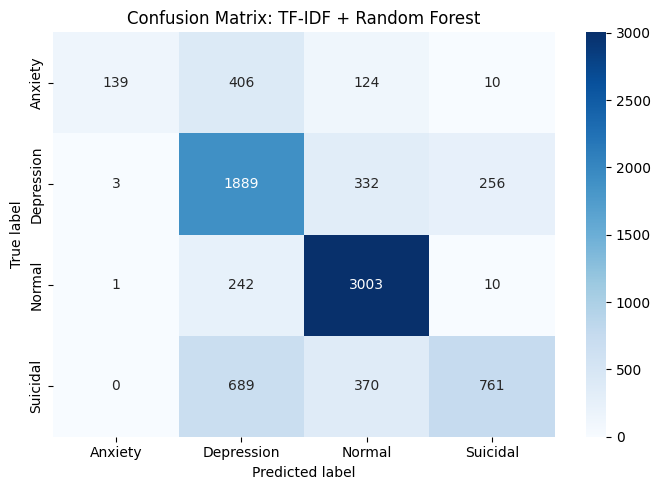

Suicidal one-vs-rest PR-AUC: 0.6524
Suicidal Average Precision:  0.6507


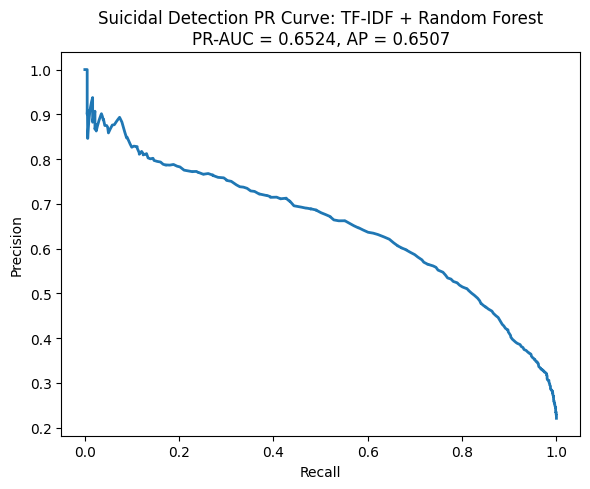


Cross-validation summary for TF-IDF + Random Forest
cv_accuracy_mean: 0.7024
cv_accuracy_std: 0.0028
cv_macro_f1_mean: 0.5903
cv_macro_f1_std: 0.0022
cv_weighted_f1_mean: 0.6784
cv_weighted_f1_std: 0.0027


In [11]:
# Model 3 (Model Improvement): TF-IDF + Random Forest

tfidf_rf = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        sublinear_tf=True,
        strip_accents="unicode"
    )),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        n_jobs=-1,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

res_tfidf_rf = evaluate_classifier(
    model_name="TF-IDF + Random Forest",
    model=tfidf_rf,
    X_train=X_train_text,
    y_train=y_train,
    X_val=X_val_text,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_tfidf_rf = cross_validate_model(
    model_name="TF-IDF + Random Forest",
    model=tfidf_rf,
    X=X_text_all,
    y=y_all
)

## Word TF-IDF + kNN

MODEL: TF-IDF + kNN
Accuracy:      0.5767
Macro F1:      0.4941
Weighted F1:   0.5383
Macro Prec.:   0.6165
Macro Recall:  0.4796

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.7154    0.2739    0.3962       679
  Depression     0.6134    0.3141    0.4155      2480
      Normal     0.5619    0.9490    0.7059      3256
    Suicidal     0.5755    0.3813    0.4587      1820

    accuracy                         0.5767      8235
   macro avg     0.6165    0.4796    0.4941      8235
weighted avg     0.5931    0.5767    0.5383      8235



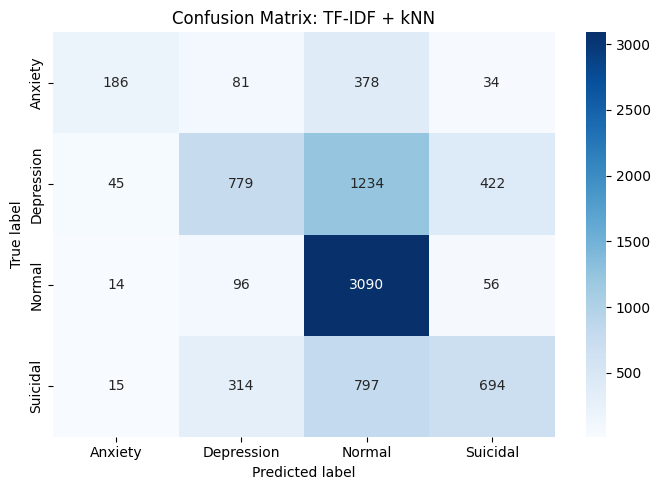

Suicidal one-vs-rest PR-AUC: 0.5444
Suicidal Average Precision:  0.5223


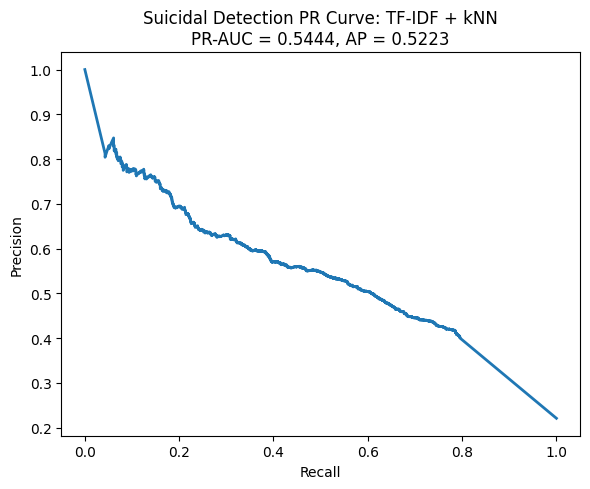


Cross-validation summary for TF-IDF + kNN
cv_accuracy_mean: 0.5866
cv_accuracy_std: 0.0053
cv_macro_f1_mean: 0.5088
cv_macro_f1_std: 0.0091
cv_weighted_f1_mean: 0.5486
cv_weighted_f1_std: 0.0063


In [12]:
# Model 4 (Model Improvement): TF-IDF + kNN

tfidf_knn = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        sublinear_tf=True,
        strip_accents="unicode"
    )),
    ("knn", KNeighborsClassifier(
        n_neighbors=5,
        weights="distance",
        metric="cosine"
    ))
])

res_tfidf_knn = evaluate_classifier(
    model_name="TF-IDF + kNN",
    model=tfidf_knn,
    X_train=X_train_text,
    y_train=y_train,
    X_val=X_val_text,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_tfidf_knn = cross_validate_model(
    model_name="TF-IDF + kNN",
    model=tfidf_knn,
    X=X_text_all,
    y=y_all
)

## Hybrid TF-IDF + SVM

**Word TF-IDF to (Word + Character) TF-IDF**

Our initial baseline model used TF-IDF with word n-grams, which represents each post based on the frequency and importance of words in the dataset. This approach is widely used in classical text classification and performed well in our early experiments.

Word n-gram analyzes normal words such as:

- depressed
- want to die

In the cases where we have spelling mistake or informal text, a standard word-based TF-IDF model may fail to recognize the words because they are misspelled or written informally. To address this limitation, we extended the feature representation to a hybrid TF-IDF model that combines word n-grams and character n-grams.

Character n-grams help the model recognize misspelled or informal text, which is common in social media posts. For example:

- “I want to kill myself”

- “I wanna kil mes”

- “im depresed and tired”

These subword patterns remain similar even when words are misspelled or abbreviated. As a result, the hybrid representation allows the model to detect linguistic patterns that would otherwise be missed by word-only TF-IDF features. This improvement is particularly important for social media and mental health text analysis, where language is often informal and inconsistent.

MODEL: Hybrid TF-IDF (word+char) + Linear SVM
Accuracy:      0.7971
Macro F1:      0.7731
Weighted F1:   0.7943
Macro Prec.:   0.7889
Macro Recall:  0.7608

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.8458    0.7187    0.7771       679
  Depression     0.7262    0.7262    0.7262      2480
      Normal     0.8900    0.9515    0.9197      3256
    Suicidal     0.6936    0.6467    0.6693      1820

    accuracy                         0.7971      8235
   macro avg     0.7889    0.7608    0.7731      8235
weighted avg     0.7936    0.7971    0.7943      8235



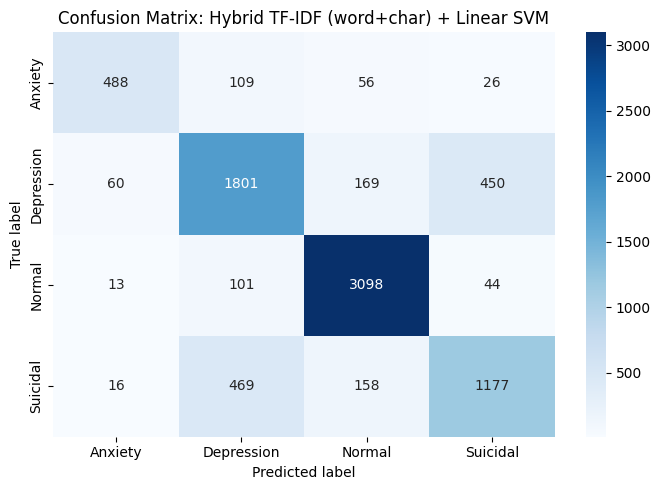

Suicidal one-vs-rest PR-AUC: 0.7225
Suicidal Average Precision:  0.7227


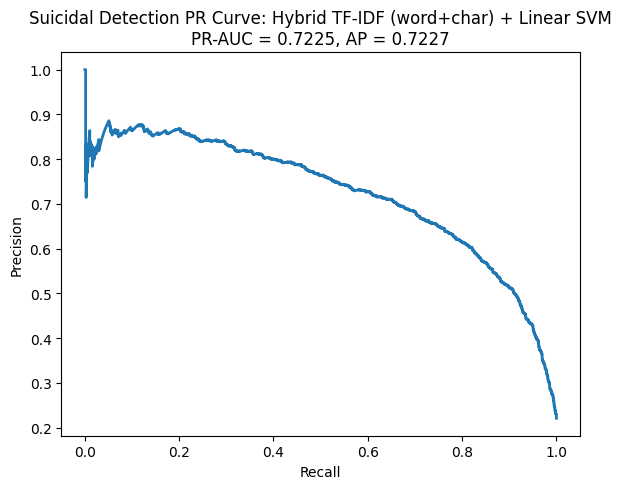


Cross-validation summary for Hybrid TF-IDF (word+char) + Linear SVM
cv_accuracy_mean: 0.7972
cv_accuracy_std: 0.0035
cv_macro_f1_mean: 0.7721
cv_macro_f1_std: 0.0036
cv_weighted_f1_mean: 0.7945
cv_weighted_f1_std: 0.0034


In [13]:
# Model 5 (Feature Improvement): Hybrid TF-IDF (word + character) + Linear SVM

word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1,2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",  # character n-grams within word boundaries
    ngram_range=(3,5),
    min_df=3,
    sublinear_tf=True
)

hybrid_tfidf = FeatureUnion([
    ("word", word_tfidf),
    ("char", char_tfidf)
])

base_hybrid_svm = Pipeline([
    ("features", hybrid_tfidf),
    ("svm", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

hybrid_svm = CalibratedClassifierCV(
    estimator=base_hybrid_svm,
    method="sigmoid",
    cv=3
)

res_hybrid_svm = evaluate_classifier(
    model_name="Hybrid TF-IDF (word+char) + Linear SVM",
    model=hybrid_svm,
    X_train=X_train_text,
    y_train=y_train,
    X_val=X_val_text,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_hybrid_svm = cross_validate_model(
    model_name="Hybrid TF-IDF (word+char) + Linear SVM",
    model=hybrid_svm,
    X=X_text_all,
    y=y_all
)

## Tuned Hybrid TF-IDF + SVM

**Parameter Tuning (Grid Search)**

Grid search was used to tune the SVM regularization parameter C, which controls the trade-off between fitting the training data and generalizing to unseen data.
- If C is too large, the model may overfit the training data.
- If C is too small, the model may underfit and fail to capture important patterns.

Because C is a continuous hyperparameter, it is not possible to evaluate all possible values directly. Instead, we approximate the search space using a logarithmically spaced grid over several orders of magnitude. Specifically, we evaluated 15 candidate values of ranging from 10^-3 to 10^3. This covers both low and high regularization parameter space.

We evaluated several candidate values using 3-fold cross-validation and selected the parameter that maximized macro-F1 score. We used macro-F1 score as the tuning metric because:
- target is multi-class
- dataset contains class imbalance
- macro-F1 evaluates performance equally across all classes

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "estimator__svm__C": np.logspace(-3, 3, 15)  # 15 values from 10^-3 to 10^3
}

grid_hybrid_svm = GridSearchCV(
    estimator=hybrid_svm,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,  # 3-fold CV
    n_jobs=-1,  # use all available CPU cores for efficiency
    verbose=1  # to monitor how many fits are being run
)

grid_hybrid_svm.fit(X_train_text, y_train)

print("Best parameters found:")
print(grid_hybrid_svm.best_params_)

print("\nBest cross-validated macro F1:")
print(grid_hybrid_svm.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters found:
{'estimator__svm__C': np.float64(0.13894954943731375)}

Best cross-validated macro F1:
0.7706702216471585


MODEL: Tuned Hybrid TF-IDF (word+char) + Linear SVM
Accuracy:      0.7983
Macro F1:      0.7743
Weighted F1:   0.7952
Macro Prec.:   0.7867
Macro Recall:  0.7645

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.8253    0.7305    0.7750       679
  Depression     0.7343    0.7165    0.7253      2480
      Normal     0.8838    0.9533    0.9173      3256
    Suicidal     0.7033    0.6577    0.6797      1820

    accuracy                         0.7983      8235
   macro avg     0.7867    0.7645    0.7743      8235
weighted avg     0.7941    0.7983    0.7952      8235



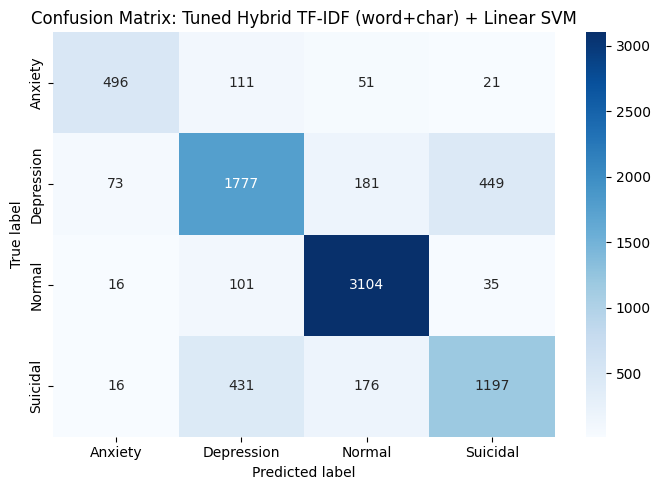

Suicidal one-vs-rest PR-AUC: 0.7274
Suicidal Average Precision:  0.7276


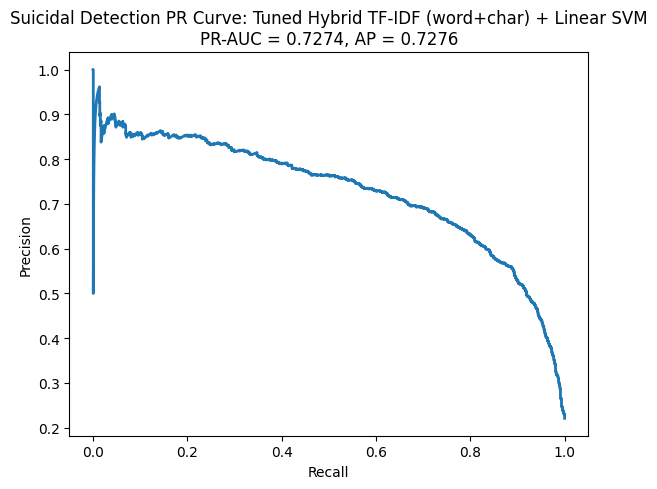


Cross-validation summary for Tuned Hybrid TF-IDF (word+char) + Linear SVM
cv_accuracy_mean: 0.8004
cv_accuracy_std: 0.0044
cv_macro_f1_mean: 0.7764
cv_macro_f1_std: 0.0048
cv_weighted_f1_mean: 0.7975
cv_weighted_f1_std: 0.0045


In [ ]:
# Model 6 (Feature Improvement): Tuned hybrid TF-IDF + SVM

tuned_hybrid_svm = grid_hybrid_svm.best_estimator_

res_tuned_hybrid_svm = evaluate_classifier(
    model_name="Tuned Hybrid TF-IDF (word+char) + Linear SVM",
    model=tuned_hybrid_svm,
    X_train=X_train_text,
    y_train=y_train,
    X_val=X_val_text,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

# Full cross-validation row for results table
cv_tuned_hybrid_svm = cross_validate_model(
    model_name="Tuned Hybrid TF-IDF (word+char) + Linear SVM",
    model=tuned_hybrid_svm,
    X=X_text_all,
    y=y_all
)

## Expanded Tuned Hybrid TF-IDF + SVM

In [17]:
# Expanded hyperparameter tuning

# Base hybrid pipeline
word_tfidf_tune = TfidfVectorizer()
char_tfidf_tune = TfidfVectorizer()

hybrid_tfidf_tune = FeatureUnion([
    ("word", word_tfidf_tune),
    ("char", char_tfidf_tune)
])

base_hybrid_svm_tune = Pipeline([
    ("features", hybrid_tfidf_tune),
    ("svm", LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

hybrid_svm_tune = CalibratedClassifierCV(
    estimator=base_hybrid_svm_tune,
    method="sigmoid",
    cv=3
)

param_grid_hybrid_expanded = {
    "estimator__features__word__analyzer": ["word"],
    "estimator__features__word__ngram_range": [(1, 1), (1, 2)],
    "estimator__features__word__min_df": [2, 3, 5],
    "estimator__features__word__max_df": [0.95, 1.0],
    "estimator__features__word__sublinear_tf": [True],
    
    "estimator__features__char__analyzer": ["char_wb"],
    "estimator__features__char__ngram_range": [(3, 5), (3, 6)],
    "estimator__features__char__min_df": [2, 3],
    "estimator__features__char__sublinear_tf": [True],
    
    # this time, use wide range of pre-specified values due to runtime issue
    "estimator__svm__C": [0.1, 0.3, 1, 3, 10] 
}

grid_hybrid_svm_expanded = GridSearchCV(
    estimator=hybrid_svm_tune,
    param_grid=param_grid_hybrid_expanded,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_hybrid_svm_expanded.fit(X_train_text, y_train)

print("Best expanded-grid parameters:")
print(grid_hybrid_svm_expanded.best_params_)

print("\nBest expanded-grid CV macro F1:")
print(grid_hybrid_svm_expanded.best_score_)

Fitting 3 folds for each of 240 candidates, totalling 720 fits
Best expanded-grid parameters:
{'estimator__features__char__analyzer': 'char_wb', 'estimator__features__char__min_df': 2, 'estimator__features__char__ngram_range': (3, 5), 'estimator__features__char__sublinear_tf': True, 'estimator__features__word__analyzer': 'word', 'estimator__features__word__max_df': 0.95, 'estimator__features__word__min_df': 2, 'estimator__features__word__ngram_range': (1, 2), 'estimator__features__word__sublinear_tf': True, 'estimator__svm__C': 0.3}

Best expanded-grid CV macro F1:
0.7714816222692683


MODEL: Expanded-Tuned Hybrid TF-IDF (word+char) + Linear SVM
Accuracy:      0.8006
Macro F1:      0.7774
Weighted F1:   0.7976
Macro Prec.:   0.7903
Macro Recall:  0.7672

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.8347    0.7364    0.7825       679
  Depression     0.7340    0.7234    0.7287      2480
      Normal     0.8875    0.9542    0.9196      3256
    Suicidal     0.7049    0.6549    0.6790      1820

    accuracy                         0.8006      8235
   macro avg     0.7903    0.7672    0.7774      8235
weighted avg     0.7966    0.8006    0.7976      8235



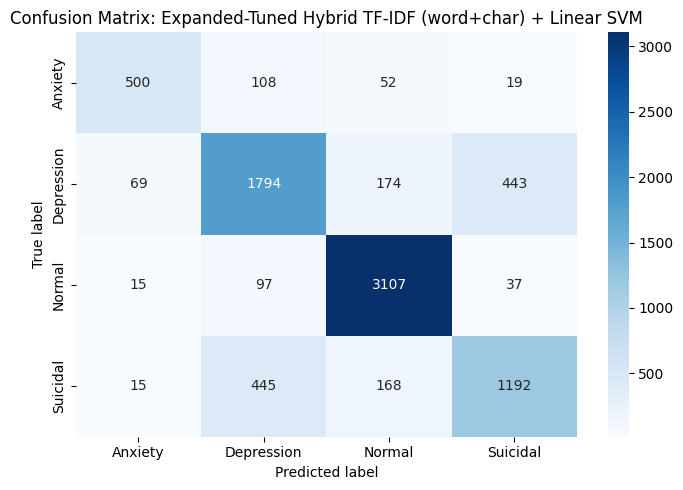

Suicidal one-vs-rest PR-AUC: 0.7291
Suicidal Average Precision:  0.7294


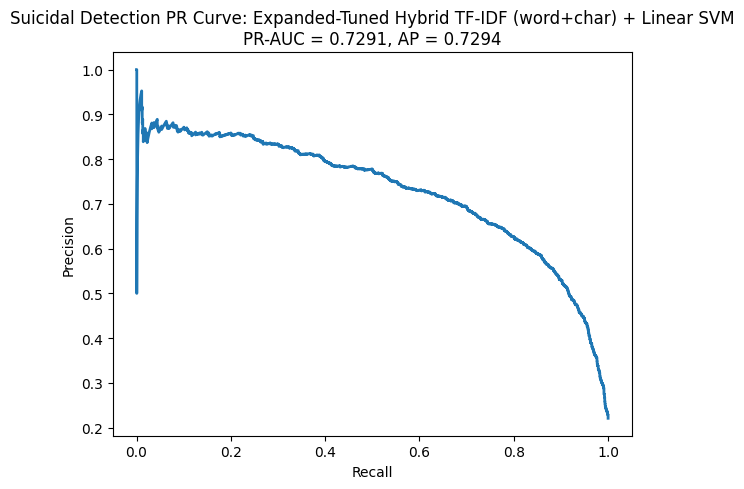


Cross-validation summary for Expanded-Tuned Hybrid TF-IDF (word+char) + Linear SVM
cv_accuracy_mean: 0.8019
cv_accuracy_std: 0.0035
cv_macro_f1_mean: 0.7780
cv_macro_f1_std: 0.0037
cv_weighted_f1_mean: 0.7993
cv_weighted_f1_std: 0.0035


,model,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,suicidal_pr_auc,suicidal_average_precision
0,Tuned Hybrid TF-IDF (word+char) + Linear SVM,0.798300,0.774323,0.795225,0.786676,0.764507,0.727357,0.727647
1,Expanded-Tuned Hybrid TF-IDF (word+char) + Lin...,0.800607,0.777449,0.797639,0.790284,0.767237,0.729148,0.729443


,model,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_weighted_f1_mean,cv_weighted_f1_std
0,Tuned Hybrid TF-IDF (word+char) + Linear SVM,0.800408,0.004427,0.776356,0.004819,0.797476,0.004471
1,Expanded-Tuned Hybrid TF-IDF (word+char) + Lin...,0.801938,0.003547,0.777998,0.003676,0.799272,0.003499


In [ ]:
# Model 7 (Feature Improvement): Expanded tuned hybrid TF-IDF + SVM

tuned_hybrid_svm_expanded = grid_hybrid_svm_expanded.best_estimator_

res_tuned_hybrid_svm_expanded = evaluate_classifier(
    model_name="Expanded-Tuned Hybrid TF-IDF (word+char) + Linear SVM",
    model=tuned_hybrid_svm_expanded,
    X_train=X_train_text,
    y_train=y_train,
    X_val=X_val_text,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_tuned_hybrid_svm_expanded = cross_validate_model(
    model_name="Expanded-Tuned Hybrid TF-IDF (word+char) + Linear SVM",
    model=tuned_hybrid_svm_expanded,
    X=X_text_all,
    y=y_all
)

display(pd.DataFrame([res_tuned_hybrid_svm, res_tuned_hybrid_svm_expanded]))
display(pd.DataFrame([cv_tuned_hybrid_svm, cv_tuned_hybrid_svm_expanded]))

## Emsemble

**Ensemble Weight Selection (Grid Search)**

We performed a grid search over possible weight combinations to optimize ensemble performance on the validation set. The objective was to maximize macro-F1 score, ensuring balanced performance across all classes.

In [19]:
# Each model is giving a probability distribution over classes on validation split
p1 = tuned_hybrid_svm_expanded.predict_proba(X_val_text)
p2 = hybrid_svm.predict_proba(X_val_text)
p3 = tfidf_svm.predict_proba(X_val_text)
p4 = tfidf_logreg.predict_proba(X_val_text)

# Ensemble weight selection over grid search
best_score = 0
best_weights = None

# define search space
w1_vals = np.arange(0.3, 0.6, 0.05)   # focus more weight on tuned hybrid svm (strongest model)
w2_vals = np.arange(0.1, 0.4, 0.05)
w3_vals = np.arange(0.1, 0.4, 0.05)

for w1 in w1_vals:
    for w2 in w2_vals:
        for w3 in w3_vals:
            w4 = 1 - (w1 + w2 + w3)

            # ensure valid weights
            if w4 < 0 or w4 > 1:
                continue

            # compute ensemble
            ensemble_probs = (
                w1 * p1 +
                w2 * p2 +
                w3 * p3 +
                w4 * p4
            )

            preds = ensemble_probs.argmax(axis=1)

            score = f1_score(y_val, preds, average="macro")

            if score > best_score:
                best_score = score
                best_weights = (w1, w2, w3, w4)

print("Best weights:", best_weights)
print("Best macro F1:", best_score)

Best weights: (np.float64(0.39999999999999997), np.float64(0.25000000000000006), np.float64(0.20000000000000004), np.float64(0.1499999999999999))
Best macro F1: 0.7783914994710367


In [20]:
from sklearn.base import BaseEstimator, ClassifierMixin, clone

# Evaluation helper
#   Since ensemble is not a single sklearn model, we have to wrap it

class WeightedEnsembleClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, models, weights):
        self.models = models
        self.weights = weights

    def fit(self, X, y):
        self.fitted_models_ = []
        for model in self.models:
            fitted_model = clone(model)
            fitted_model.fit(X, y)
            self.fitted_models_.append(fitted_model)

        self.classes_ = self.fitted_models_[0].classes_
        return self

    def predict_proba(self, X):
        probs = None
        for weight, model in zip(self.weights, self.fitted_models_):
            model_probs = model.predict_proba(X)
            if probs is None:
                probs = weight * model_probs
            else:
                probs += weight * model_probs
        return probs

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)


MODEL: Weighted Ensemble of 4 Non-Transformer Models
Accuracy:      0.8013
Macro F1:      0.7784
Weighted F1:   0.7987
Macro Prec.:   0.7899
Macro Recall:  0.7691

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.8308    0.7378    0.7816       679
  Depression     0.7380    0.7190    0.7283      2480
      Normal     0.8906    0.9524    0.9205      3256
    Suicidal     0.7001    0.6670    0.6832      1820

    accuracy                         0.8013      8235
   macro avg     0.7899    0.7691    0.7784      8235
weighted avg     0.7976    0.8013    0.7987      8235



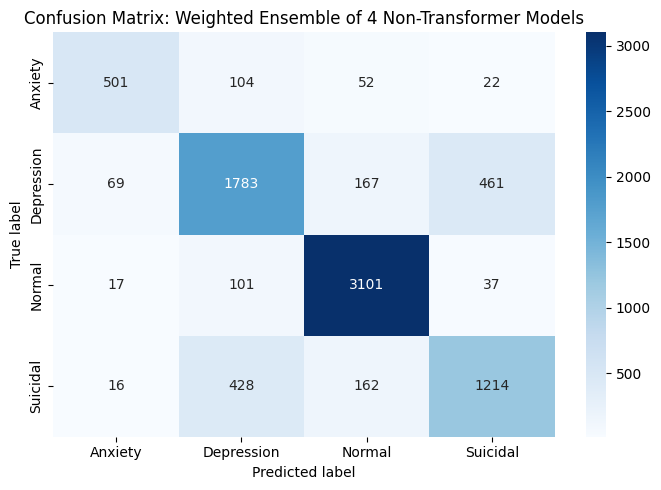

Suicidal one-vs-rest PR-AUC: 0.7295
Suicidal Average Precision:  0.7298


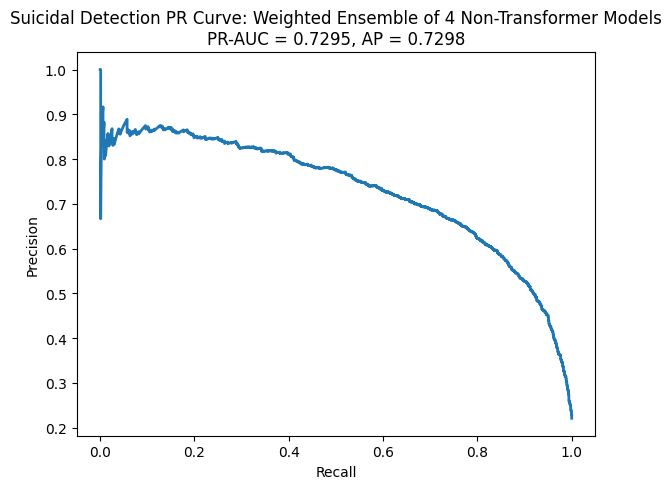


Cross-validation summary for Weighted Ensemble of 4 Non-Transformer Models
cv_accuracy_mean: 0.8018
cv_accuracy_std: 0.0040
cv_macro_f1_mean: 0.7783
cv_macro_f1_std: 0.0040
cv_weighted_f1_mean: 0.7992
cv_weighted_f1_std: 0.0040


In [21]:
# Model 8: Ensemble 4 Models
# - Word TF-IDF + LR
# - Word TF-IDF + SVM
# - Hybrid TF-IDF + SVM
# - Expanded Tuned Hybrid TF-IDF + SVM


# Use the best weights found above
w1, w2, w3, w4 = best_weights

ensemble_probs = (
    w1 * p1 +
    w2 * p2 +
    w3 * p3 +
    w4 * p4
)

ensemble_pred = ensemble_probs.argmax(axis=1)

ensemble_4models = WeightedEnsembleClassifier(
    models=[tuned_hybrid_svm_expanded, hybrid_svm, tfidf_svm, tfidf_logreg],
    weights=list(best_weights)
)

res_ensemble_4models = evaluate_classifier(
    model_name="Weighted Ensemble of 4 Non-Transformer Models",
    model=ensemble_4models,
    X_train=X_train_text,
    y_train=y_train,
    X_val=X_val_text,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_ensemble_4models = cross_validate_model(
    model_name="Weighted Ensemble of 4 Non-Transformer Models",
    model=ensemble_4models,
    X=X_text_all,
    y=y_all
)

# 5. Sentence Embedding Models

In [49]:
# Feature Representation: Sentence embeddings
embedding_model_name = "all-MiniLM-L6-v2"
embedding_model = SentenceTransformer(embedding_model_name)

# Encode the labeled train data and unlabeled test data
# convert_to_numpy=True returns standard NumPy arrays
X_embed_all = embedding_model.encode(
    train_df["clean_text_model"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

X_embed_test = embedding_model.encode(
    test_df["clean_text_model"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

# Split embeddings using the same train/validation indices as before
X_embed_train = X_embed_all[idx_train]
X_embed_val = X_embed_all[idx_val]

print("Embedding train shape:", X_embed_train.shape)
print("Embedding val shape:", X_embed_val.shape)
print("Embedding test shape:", X_embed_test.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/644 [00:00<?, ?it/s]

Batches:   0%|          | 0/132 [00:00<?, ?it/s]

Embedding train shape: (32939, 384)
Embedding val shape: (8235, 384)
Embedding test shape: (8436, 384)


## Sent-Embedding + LR

MODEL: Sentence Embeddings + Logistic Regression
Accuracy:      0.7682
Macro F1:      0.7364
Weighted F1:   0.7684
Macro Prec.:   0.7218
Macro Recall:  0.7676

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.5769    0.8395    0.6839       679
  Depression     0.7408    0.6028    0.6647      2480
      Normal     0.9191    0.9036    0.9113      3256
    Suicidal     0.6504    0.7247    0.6856      1820

    accuracy                         0.7682      8235
   macro avg     0.7218    0.7676    0.7364      8235
weighted avg     0.7778    0.7682    0.7684      8235



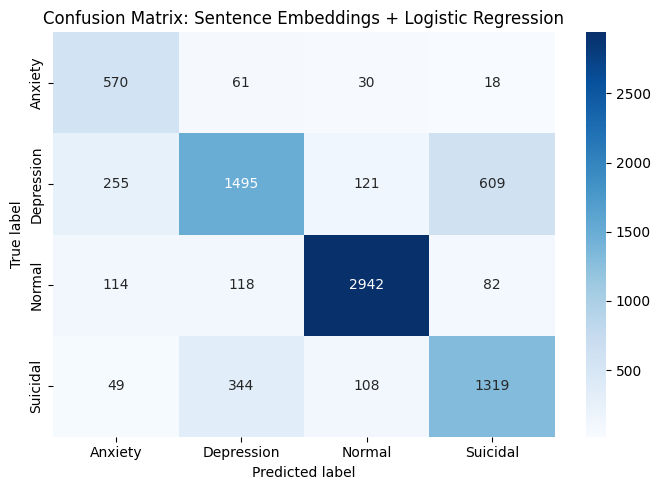

Suicidal one-vs-rest PR-AUC: 0.6958
Suicidal Average Precision:  0.6960


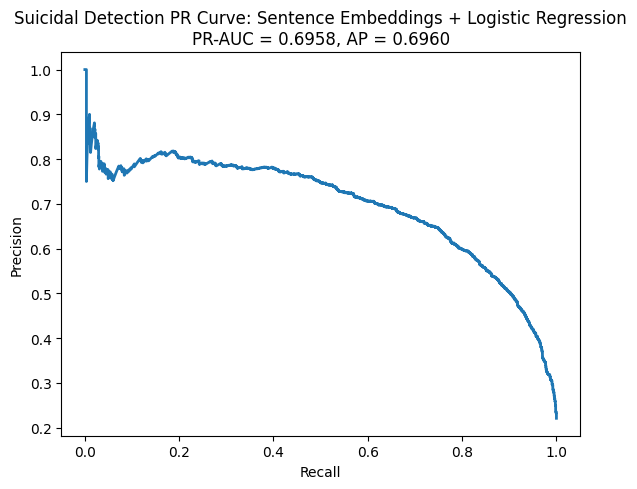


Cross-validation summary for Sentence Embeddings + Logistic Regression
cv_accuracy_mean: 0.7659
cv_accuracy_std: 0.0039
cv_macro_f1_mean: 0.7341
cv_macro_f1_std: 0.0043
cv_weighted_f1_mean: 0.7662
cv_weighted_f1_std: 0.0040


In [50]:
# Model 9 (Feature Improvement): Sentence Embeddings + Multinomial Logistic Regression

embed_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        solver="saga",
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

res_embed_logreg = evaluate_classifier(
    model_name="Sentence Embeddings + Logistic Regression",
    model=embed_logreg,
    X_train=X_embed_train,
    y_train=y_train,
    X_val=X_embed_val,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_embed_logreg = cross_validate_model(
    model_name="Sentence Embeddings + Logistic Regression",
    model=embed_logreg,
    X=X_embed_all,
    y=y_all
)

## Sent-Embedding + SVM

MODEL: Sentence Embeddings + Calibrated Linear SVM
Accuracy:      0.7806
Macro F1:      0.7483
Weighted F1:   0.7774
Macro Prec.:   0.7616
Macro Recall:  0.7380

Classification report:
              precision    recall  f1-score   support

     Anxiety     0.7749    0.6642    0.7153       679
  Depression     0.7092    0.6931    0.7011      2480
      Normal     0.8798    0.9441    0.9108      3256
    Suicidal     0.6824    0.6505    0.6661      1820

    accuracy                         0.7806      8235
   macro avg     0.7616    0.7380    0.7483      8235
weighted avg     0.7761    0.7806    0.7774      8235



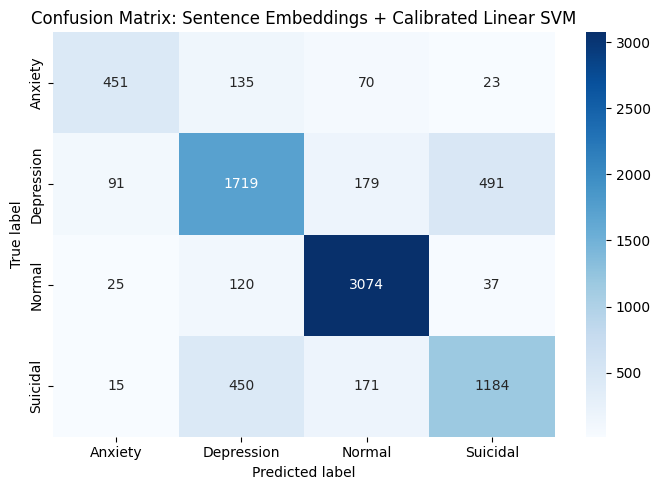

Suicidal one-vs-rest PR-AUC: 0.6974
Suicidal Average Precision:  0.6977


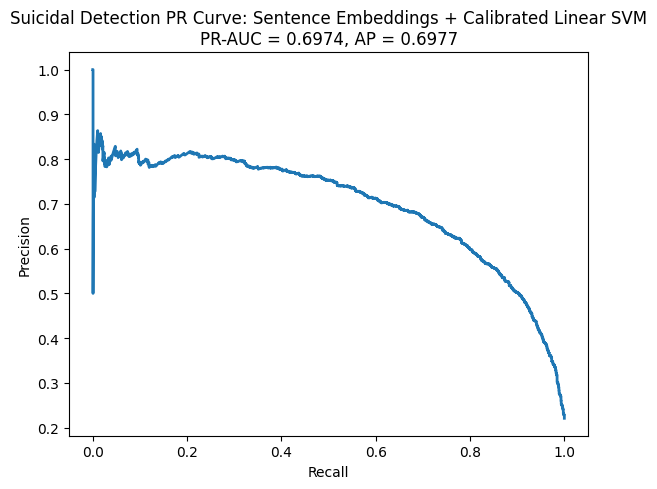


Cross-validation summary for Sentence Embeddings + Calibrated Linear SVM
cv_accuracy_mean: 0.7759
cv_accuracy_std: 0.0050
cv_macro_f1_mean: 0.7421
cv_macro_f1_std: 0.0067
cv_weighted_f1_mean: 0.7728
cv_weighted_f1_std: 0.0051


In [51]:
# Model 10 (Feature Improvement): Sentence Embeddings + Linear SVM

base_embed_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

embed_svm = CalibratedClassifierCV(
    estimator=base_embed_svm,
    method="sigmoid",
    cv=3
)

res_embed_svm = evaluate_classifier(
    model_name="Sentence Embeddings + Calibrated Linear SVM",
    model=embed_svm,
    X_train=X_embed_train,
    y_train=y_train,
    X_val=X_embed_val,
    y_val=y_val,
    class_names=label_encoder.classes_,
    has_predict_proba=True
)

cv_embed_svm = cross_validate_model(
    model_name="Sentence Embeddings + Calibrated Linear SVM",
    model=embed_svm,
    X=X_embed_all,
    y=y_all
)

# 6. Contextual Transformer Models
## DistilBERT

In [22]:
from datasets import Dataset
import evaluate
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

# prepare labels
label_encoder = LabelEncoder()
train_df["label"] = label_encoder.fit_transform(train_df["status"])

print("Label mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

Label mapping:
0 -> Anxiety
1 -> Depression
2 -> Normal
3 -> Suicidal


In [23]:
# Train/validation split (just for BERT)
RANDOM_STATE = 42

bert_train_df, bert_val_df = train_test_split(
    train_df[["clean_text_model", "label"]].copy(),
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=train_df["label"]
)

bert_train_df = bert_train_df.reset_index(drop=True)
bert_val_df = bert_val_df.reset_index(drop=True)

print("Train size:", bert_train_df.shape)
print("Validation size:", bert_val_df.shape)

Train size: (32939, 2)
Validation size: (8235, 2)


In [24]:
# Turns pandas DataFrames into the dataset format expected by Hugging Face
ds_train = Dataset.from_pandas(
    pd.DataFrame({
        "text": bert_train_df["clean_text_model"].values,
        "label": bert_train_df["label"].values
    }),
    preserve_index=False
)

ds_val = Dataset.from_pandas(
    pd.DataFrame({
        "text": bert_val_df["clean_text_model"].values,
        "label": bert_val_df["label"].values
    }),
    preserve_index=False
)

ds_test = Dataset.from_pandas(
    pd.DataFrame({
        "text": test_df["clean_text_model"].values
    }),
    preserve_index=False
)

In [25]:
# tokenizer and tokenization
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

MAX_LENGTH = 256

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_train = ds_train.map(tokenize_batch, batched=True)
tokenized_val = ds_val.map(tokenize_batch, batched=True)
tokenized_test = ds_test.map(tokenize_batch, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/32939 [00:00<?, ? examples/s]

Map:   0%|          | 0/8235 [00:00<?, ? examples/s]

Map:   0%|          | 0/8436 [00:00<?, ? examples/s]

In [26]:
# metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "macro_f1": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
        "weighted_f1": f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"],
        "macro_precision": precision_metric.compute(predictions=preds, references=labels, average="macro")["precision"],
        "macro_recall": recall_metric.compute(predictions=preds, references=labels, average="macro")["recall"],
    }

In [27]:
# Label dictionaries and class weights
id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in enumerate(label_encoder.classes_)}

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(bert_train_df["label"]),
    y=bert_train_df["label"]
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print("Class weights:", class_weights)
print("id2label:", id2label)

Class weights: tensor([3.0331, 0.8304, 0.6322, 1.1308])
id2label: {0: 'Anxiety', 1: 'Depression', 2: 'Normal', 3: 'Suicidal'}


In [28]:
# Weighted Trainer
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
        )
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [29]:
# Load DistilBERT model
bert_model_improved = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_encoder.classes_),
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [32]:
# Training arguments
improved_training_args = TrainingArguments(
    output_dir="./distilbert_mental_health_improved",
    learning_rate=1e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=1,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    fp16=True,
    dataloader_num_workers=4
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [93]:
# Train improved DistilBERT
trainer_improved = WeightedTrainer(
    model=bert_model_improved,
    args=improved_training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer_improved.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,0.180181,0.903971,0.799757,0.775079,0.797998,0.769820,0.787523
2,0.160477,0.788667,0.805586,0.787476,0.806202,0.783500,0.791914
3,0.186431,0.779908,0.802064,0.780707,0.801683,0.772983,0.790602
4,0.157489,0.805334,0.806436,0.786610,0.806143,0.782367,0.791347


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=4120, training_loss=0.1711447817607991, metrics={'train_runtime': 523.1734, 'train_samples_per_second': 314.8, 'train_steps_per_second': 9.844, 'total_flos': 8337930247027416.0, 'train_loss': 0.1711447817607991, 'epoch': 4.0})

In [34]:
# Validation evaluation
bert_pred_output_improved = trainer_improved.predict(tokenized_val)

bert_logits_improved = bert_pred_output_improved.predictions
bert_y_true_improved = bert_pred_output_improved.label_ids
bert_y_pred_improved = np.argmax(bert_logits_improved, axis=1)

print(classification_report(
    bert_y_true_improved,
    bert_y_pred_improved,
    target_names=label_encoder.classes_,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

     Anxiety     0.7746    0.8351    0.8037       679
  Depression     0.7707    0.7008    0.7341      2480
      Normal     0.9371    0.9248    0.9309      3256
    Suicidal     0.6865    0.7676    0.7248      1820

    accuracy                         0.8152      8235
   macro avg     0.7922    0.8070    0.7984      8235
weighted avg     0.8182    0.8152    0.8156      8235



In [35]:
# DistilBERT validation metrics row (to add into results)

def softmax_numpy(x):
    x = np.asarray(x)
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

bert_val_proba_improved = softmax_numpy(bert_logits_improved)

bert_pr_dict_improved = suicidal_pr_auc_from_probs(
    y_true=bert_y_true_improved,
    y_prob=bert_val_proba_improved,
    class_names=label_encoder.classes_
)

res_distilbert_improved = {
    "model": "DistilBERT (improved fine-tuning)",
    "accuracy": accuracy_score(bert_y_true_improved, bert_y_pred_improved),
    "macro_f1": f1_score(bert_y_true_improved, bert_y_pred_improved, average="macro"),
    "weighted_f1": f1_score(bert_y_true_improved, bert_y_pred_improved, average="weighted"),
    "macro_precision": precision_score(bert_y_true_improved, bert_y_pred_improved, average="macro", zero_division=0),
    "macro_recall": recall_score(bert_y_true_improved, bert_y_pred_improved, average="macro", zero_division=0),
    "suicidal_pr_auc": bert_pr_dict_improved["pr_auc"],
    "suicidal_average_precision": bert_pr_dict_improved["average_precision"]
}

print(res_distilbert_improved)

{'model': 'DistilBERT (improved fine-tuning)', 'accuracy': 0.8151791135397692, 'macro_f1': 0.7983668203412408, 'weighted_f1': 0.8155908600321521, 'macro_precision': 0.7922346913641573, 'macro_recall': 0.8070486788353433, 'suicidal_pr_auc': 0.7650665903059531, 'suicidal_average_precision': 0.7651718659502045}


## RoBERTa

In [36]:
ROBERTA_CKPT    = "mental/mental-roberta-base"  # falls back to roberta-base if unavailable
ROBERTA_MAX_LEN = 256       # longer than DistilBERT's 128 — catches full post context
ROBERTA_LR      = 1e-5
ROBERTA_EPOCHS  = 5
ROBERTA_BATCH   = 16
ROBERTA_GRAD_ACC= 1
ROBERTA_SMOOTH  = 0.05
ROBERTA_DECAY   = 0.01
ROBERTA_WARMUP  = 0.10
ROBERTA_PATIENCE= 2

In [37]:
# Tokenizer
print(f"Loading tokeniser: {ROBERTA_CKPT}")
try:
    roberta_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_CKPT)
    roberta_ckpt_used = ROBERTA_CKPT
except Exception:
    print("  mental-roberta-base unavailable — falling back to roberta-base")
    roberta_tokenizer = AutoTokenizer.from_pretrained("roberta-base")
    roberta_ckpt_used = "roberta-base"
 
def roberta_tokenize(batch):
    return roberta_tokenizer(
        batch["text"],
        truncation=True,
        max_length=ROBERTA_MAX_LEN,
    )

Loading tokeniser: mental/mental-roberta-base
  mental-roberta-base unavailable — falling back to roberta-base


In [38]:
# Train / val split (same 80/20 stratified split as DistilBERT section)
from sklearn.model_selection import train_test_split
 
roberta_train_df, roberta_val_df = train_test_split(
    train_df[["clean_text_model", "label"]].copy(),
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=train_df["label"],
)
roberta_train_df = roberta_train_df.reset_index(drop=True)
roberta_val_df   = roberta_val_df.reset_index(drop=True)

In [39]:
# HuggingFace datasets
roberta_ds_train = Dataset.from_dict({
    "text":  roberta_train_df["clean_text_model"].tolist(),
    "label": roberta_train_df["label"].tolist(),
})
roberta_ds_val = Dataset.from_dict({
    "text":  roberta_val_df["clean_text_model"].tolist(),
    "label": roberta_val_df["label"].tolist(),
})
roberta_ds_test = Dataset.from_dict({
    "text": test_df["clean_text_model"].tolist(),
})
 
roberta_ds_train = roberta_ds_train.map(roberta_tokenize, batched=True)
roberta_ds_val   = roberta_ds_val.map(roberta_tokenize,   batched=True)
roberta_ds_test  = roberta_ds_test.map(roberta_tokenize,  batched=True)
 
roberta_collator = DataCollatorWithPadding(tokenizer=roberta_tokenizer)

Map:   0%|          | 0/32939 [00:00<?, ? examples/s]

Map:   0%|          | 0/8235 [00:00<?, ? examples/s]

Map:   0%|          | 0/8436 [00:00<?, ? examples/s]

In [40]:
# Class weights
roberta_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(roberta_train_df["label"]),
    y=roberta_train_df["label"],
)
roberta_class_weights = torch.tensor(roberta_class_weights, dtype=torch.float)
print("RoBERTa class weights:", roberta_class_weights)

RoBERTa class weights: tensor([3.0331, 0.8304, 0.6322, 1.1308])


In [41]:
# Label dicts (reuse label_encoder from before)
roberta_id2label = {i: c for i, c in enumerate(label_encoder.classes_)}
roberta_label2id = {c: i for i, c in enumerate(label_encoder.classes_)}

In [ ]:
# Custom trainer: class-weighted loss + label smoothing
# label_smoothing prevents overconfidence on Suicidal/Depression boundary
class RobertaWeightedTrainer(Trainer):
    def __init__(self, class_weights, label_smoothing=0.05, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights   = class_weights
        self.label_smoothing = label_smoothing
 
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.get("labels")
        outputs = model(**inputs)
        logits  = outputs.get("logits")
        n_cls   = logits.size(-1)
 
        # Smooth targets: 1-ε on true class, ε/(n-1) elsewhere
        smooth = torch.full_like(logits, self.label_smoothing / (n_cls - 1))
        smooth.scatter_(1, labels.unsqueeze(1), 1.0 - self.label_smoothing)
 
        log_probs = nn.functional.log_softmax(logits, dim=-1)
        per_sample = -(smooth * log_probs).sum(dim=-1)
        per_sample = per_sample * self.class_weights.to(logits.device)[labels]
        loss = per_sample.mean()
 
        return (loss, outputs) if return_outputs else loss

In [ ]:
# Metrics
try:
    _acc = evaluate.load("accuracy")
    _f1  = evaluate.load("f1")
except Exception:
    _acc = accuracy_metric
    _f1  = f1_metric
 
def roberta_compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": _acc.compute(predictions=preds, references=labels)["accuracy"],
        "macro_f1": _f1.compute(predictions=preds, references=labels, average="macro")["f1"],
        "weighted_f1": _f1.compute(predictions=preds, references=labels, average="weighted")["f1"],
    }
 

In [44]:
# Load model
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    roberta_ckpt_used,
    num_labels=len(label_encoder.classes_),
    id2label=roberta_id2label,
    label2id=roberta_label2id,
    ignore_mismatched_sizes=True,
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [45]:
# Training args
roberta_training_args = TrainingArguments(
    output_dir="./roberta_mental_health",
    learning_rate=ROBERTA_LR,
    per_device_train_batch_size=ROBERTA_BATCH,
    per_device_eval_batch_size=ROBERTA_BATCH,
    gradient_accumulation_steps=ROBERTA_GRAD_ACC,
    num_train_epochs=ROBERTA_EPOCHS,
    weight_decay=ROBERTA_DECAY,
    warmup_ratio=ROBERTA_WARMUP,
    lr_scheduler_type="cosine",       # smoother than linear, better for minority classes
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,
    logging_strategy="epoch",
    report_to="none",
    fp16=True,
    dataloader_num_workers=2
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [46]:
# Train
roberta_trainer = RobertaWeightedTrainer(
    class_weights=roberta_class_weights,
    label_smoothing=ROBERTA_SMOOTH,
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=roberta_ds_train,
    eval_dataset=roberta_ds_val,
    data_collator=roberta_collator,
    compute_metrics=roberta_compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=ROBERTA_PATIENCE)],
)
 
roberta_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.813812,0.687159,0.802550,0.774401,0.802949
2,0.612029,0.623656,0.824408,0.798348,0.824812
3,0.531021,0.662959,0.839101,0.820300,0.838899
4,0.472756,0.666071,0.837280,0.817055,0.837220
5,0.440075,0.676496,0.835337,0.815113,0.835414


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=10295, training_loss=0.573938587072001, metrics={'train_runtime': 943.9049, 'train_samples_per_second': 174.483, 'train_steps_per_second': 10.907, 'total_flos': 1.897085124853277e+16, 'train_loss': 0.573938587072001, 'epoch': 5.0})

In [47]:
# Evaluate on validation set
roberta_val_output  = roberta_trainer.predict(roberta_ds_val)
roberta_logits_val  = roberta_val_output.predictions
roberta_y_true      = roberta_val_output.label_ids
roberta_y_pred      = np.argmax(roberta_logits_val, axis=1)
roberta_val_proba   = softmax_numpy(roberta_logits_val)  
 
print("\nRoBERTa classification report:")
print(classification_report(
    roberta_y_true, roberta_y_pred,
    target_names=label_encoder.classes_,
    digits=4, zero_division=0,
))
 
roberta_pr_dict = suicidal_pr_auc_from_probs(  
    y_true=roberta_y_true,
    y_prob=roberta_val_proba,
    class_names=label_encoder.classes_,
)
 
res_roberta = {
    "model":                     "mental-roberta-base (fine-tuned)",
    "accuracy":                  accuracy_score(roberta_y_true, roberta_y_pred),
    "macro_f1":                  f1_score(roberta_y_true, roberta_y_pred, average="macro"),
    "weighted_f1":               f1_score(roberta_y_true, roberta_y_pred, average="weighted"),
    "macro_precision":           precision_score(roberta_y_true, roberta_y_pred, average="macro", zero_division=0),
    "macro_recall":              recall_score(roberta_y_true, roberta_y_pred, average="macro", zero_division=0),
    "suicidal_pr_auc":           roberta_pr_dict["pr_auc"],
    "suicidal_average_precision":roberta_pr_dict["average_precision"],
}
print("\nRoBERTa result row:")
display(pd.DataFrame([res_roberta]))


RoBERTa classification report:
              precision    recall  f1-score   support

     Anxiety     0.8054    0.8351    0.8200       679
  Depression     0.7728    0.7762    0.7745      2480
      Normal     0.9469    0.9481    0.9475      3256
    Suicidal     0.7466    0.7302    0.7383      1820

    accuracy                         0.8389      8235
   macro avg     0.8179    0.8224    0.8201      8235
weighted avg     0.8385    0.8389    0.8387      8235


RoBERTa result row:


,model,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,suicidal_pr_auc,suicidal_average_precision
0,mental-roberta-base (fine-tuned),0.838859,0.820074,0.83866,0.817935,0.822394,0.804259,0.80435


# 7. Total Results

In [94]:
# Validation results table

all_results = [
    res_tfidf_logreg,
    res_tfidf_svm,
    res_hybrid_svm,
    res_tuned_hybrid_svm,
    res_tuned_hybrid_svm_expanded,
    res_ensemble_4models,
    res_embed_logreg,
    res_embed_svm,
    res_tfidf_rf,
    res_tfidf_knn,
    res_distilbert_improved,
    res_roberta
]

results_df = pd.DataFrame(all_results)

# Sort mainly by macro F1, then suicidal PR-AUC, then accuracy
sort_cols = [c for c in ["macro_f1", "suicidal_pr_auc", "accuracy"] if c in results_df.columns]
results_df = results_df.sort_values(sort_cols, ascending=False).reset_index(drop=True)

display(results_df)

,model,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,suicidal_pr_auc,suicidal_average_precision
0,mental-roberta-base (fine-tuned),0.838859,0.820074,0.838660,0.817935,0.822394,0.804259,0.804350
1,DistilBERT (improved fine-tuning),0.815179,0.798367,0.815591,0.792235,0.807049,0.765067,0.765172
2,Weighted Ensemble of 4 Non-Transformer Models,0.801336,0.778391,0.798710,0.789884,0.769057,0.729549,0.729817
3,Expanded-Tuned Hybrid TF-IDF (word+char) + Lin...,0.800607,0.777449,0.797639,0.790284,0.767237,0.729148,0.729443
4,Tuned Hybrid TF-IDF (word+char) + Linear SVM,0.798300,0.774323,0.795225,0.786676,0.764507,0.727357,0.727647
5,Hybrid TF-IDF (word+char) + Linear SVM,0.797086,0.773074,0.794332,0.788879,0.760773,0.722458,0.722725
6,TF-IDF + Calibrated Linear SVM,0.792471,0.767362,0.789422,0.785877,0.753462,0.723203,0.723410
7,TF-IDF + Multinomial Logistic Regression,0.786400,0.763175,0.785203,0.755260,0.773881,0.716606,0.716800
8,Sentence Embeddings + Calibrated Linear SVM,0.780571,0.748321,0.777443,0.761572,0.738002,0.697362,0.697724
9,Sentence Embeddings + Logistic Regression,0.768185,0.736353,0.768386,0.721809,0.767645,0.695757,0.696011


In [53]:
!pip install dataframe-image

   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   ---------------------------------------- 6.7/6.7 MB 51.2 MB/s  0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 4.0/4.0 MB 80.3 MB/s  0:00:00
   ---------------------------------------- 0.0/36.8 MB ? eta -:--:--
   ---------------- ----------------------- 15.2/36.8 MB 73.6 MB/s eta 0:00:01
   ----------------------------------- ---- 32.5/36.8 MB 79.4 MB/s eta 0:00:01
   ---------------------------------------- 36.8/36.8 MB 66.8 MB/s  0:00:00

   ----- ---------------------------------- 1/8 [more-itertools]
   ---------- ----------------------------- 2/8 [lxml]
   ---------- ----------------------------- 2/8 [lxml]
   ---------- ----------------------------- 2/8 [lxml]
   ---------- ----------------------------- 2/8 [lxml]
   ---------- ----------------------------- 2/8 [lxml]
   --------------- ------------------------ 3/8 [greenlet]
   -------

In [58]:
# Save validation result table as an image for report

import dataframe_image as dfi

results_df_clean = results_df.copy()

# Round values for better readability
numeric_cols = results_df_clean.select_dtypes(include=[np.number]).columns
results_df_clean[numeric_cols] = results_df_clean[numeric_cols].round(4)

# Remove trailing zeros
for col in numeric_cols:
    results_df_clean[col] = results_df_clean[col].map(
        lambda x: f"{x:.3f}".rstrip("0").rstrip(".") if pd.notnull(x) else x
    )

# Rename columns for better readability
results_df_clean = results_df_clean.rename(columns={
    "macro_f1": "Macro F1",
    "weighted_f1": "Weighted F1",
    "macro_precision": "Macro Precision",
    "macro_recall": "Macro Recall",
    "suicidal_pr_auc": "PR-AUC (Suicidal)",
    "suicidal_average_precision": "Avg Precision (Suicidal)",
    "accuracy": "Accuracy"
})

# Shorten model names for better readability
results_df_clean["model"] = results_df_clean["model"].replace({
    "mental-roberta-base (fine-tuned)": "RoBERTa",
    "DistilBERT (improved fine-tuning)": "DistilBERT",
    "Weighted Ensemble of 4 Non-Transformer Models": "Ensemble (4 models)",
    "Expanded-Tuned Hybrid TF-IDF (word+char) + Linear SVM": "Expanded-Tuned Hybrid TF-IDF SVM",
    "Tuned Hybrid TF-IDF (word+char) + Linear SVM": "Tuned Hybrid TF-IDF + SVM",
    "Hybrid TF-IDF (word+char) + Linear SVM": "Hybrid TF-IDF + SVM",
    "TF-IDF + Calibrated Linear SVM": "TF-IDF + SVM (Calibrated)",
    "TF-IDF + Multinomial Logistic Regression": "TF-IDF + LogReg",
    "Sentence Embeddings + Calibrated Linear SVM": "Embeddings + SVM",
    "Sentence Embeddings + Logistic Regression": "Embeddings + LogReg",
    "TF-IDF + Random Forest": "TF-IDF + RF",
    "TF-IDF + kNN": "TF-IDF + kNN"
})


def highlight_max(s):
    return ['font-weight: bold' if v == s.max() else '' for v in s]

styled = results_df_clean.style.apply(highlight_max, subset=[
    "Accuracy", "Macro F1", "Weighted F1",
    "Macro Precision", "Macro Recall",
    "PR-AUC (Suicidal)", "Avg Precision (Suicidal)"
])

dfi.export(
    styled.hide(axis="index"),
    "validation_model_results.png",
    table_conversion="matplotlib"
)

In [95]:
# Cross-validation results table
#   DistilBERT, RoBERTa models are dropped for CV

cv_results_rows = [
    cv_tfidf_logreg,
    cv_tfidf_svm,
    cv_hybrid_svm,
    cv_tuned_hybrid_svm,
    cv_tuned_hybrid_svm_expanded,
    cv_tfidf_rf,
    cv_tfidf_knn,
    cv_ensemble_4models,
    cv_embed_logreg,
    cv_embed_svm
]

cv_results_df = pd.DataFrame(cv_results_rows)

cv_results_df = cv_results_df.sort_values(
    by=["cv_macro_f1_mean", "cv_accuracy_mean"],
    ascending=False,
    na_position="last"
).reset_index(drop=True)

display(cv_results_df)


,model,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_weighted_f1_mean,cv_weighted_f1_std
0,Weighted Ensemble of 4 Non-Transformer Models,0.801841,0.003997,0.778258,0.004000,0.799201,0.004018
1,Expanded-Tuned Hybrid TF-IDF (word+char) + Lin...,0.801938,0.003547,0.777998,0.003676,0.799272,0.003499
2,Tuned Hybrid TF-IDF (word+char) + Linear SVM,0.800408,0.004427,0.776356,0.004819,0.797476,0.004471
3,Hybrid TF-IDF (word+char) + Linear SVM,0.797178,0.003527,0.772066,0.003572,0.794478,0.003426
4,TF-IDF + Calibrated Linear SVM,0.793146,0.003069,0.767220,0.003953,0.789985,0.003138
5,TF-IDF + Multinomial Logistic Regression,0.787924,0.005137,0.763944,0.005298,0.786732,0.005062
6,Sentence Embeddings + Calibrated Linear SVM,0.775853,0.005007,0.742069,0.006661,0.772817,0.005077
7,Sentence Embeddings + Logistic Regression,0.765920,0.003908,0.734133,0.004312,0.766161,0.003982
8,TF-IDF + Random Forest,0.702385,0.002781,0.590268,0.002227,0.678434,0.002727
9,TF-IDF + kNN,0.586608,0.005283,0.508790,0.009069,0.548573,0.006284


In [61]:
# Save CV result table as an image for report

cv_display = cv_results_df.copy()
# drop best_C column
cv_display = cv_display.drop(columns=["best_C"], errors="ignore")
cv_display = cv_display.round(4)
cv_display = cv_display.map(
    lambda x: f"{x:.3f}".rstrip("0").rstrip(".")
    if isinstance(x, (float, np.floating))
    else x
)


cv_display = cv_display.rename(columns={
    "cv_accuracy_mean": "Accuracy (CV)",
    "cv_accuracy_std": "Accuracy Std",
    "cv_macro_f1_mean": "Macro F1 (CV)",
    "cv_macro_f1_std": "F1 Std",
    "cv_weighted_f1_mean": "Weighted F1 (CV)",
    "cv_weighted_f1_std": "Weighted F1 Std"
})

cv_display["model"] = cv_display["model"].replace({
    "Expanded-Tuned Hybrid TF-IDF (word+char) + Linear SVM": "Expanded-Tuned Hybrid TF-IDF SVM",
    "Weighted Ensemble of 4 Non-Transformer Models": "Ensemble (4 models)",
    "Tuned Hybrid TF-IDF (word+char) + Linear SVM": "Tuned Hybrid TF-IDF + SVM",
    "Hybrid TF-IDF (word+char) + Linear SVM": "Hybrid TF-IDF + SVM",
    "TF-IDF + Calibrated Linear SVM": "TF-IDF + SVM (Calibrated)",
    "TF-IDF + Multinomial Logistic Regression": "TF-IDF + LogReg",
    "Sentence Embeddings + Calibrated Linear SVM": "Embeddings + SVM",
    "Sentence Embeddings + Logistic Regression": "Embeddings + LogReg",
    "TF-IDF + Random Forest": "TF-IDF + RF",
    "TF-IDF + kNN": "TF-IDF + kNN"
})

def highlight_max(s):
    return ['font-weight: bold' if v == s.max() else '' for v in s]

styled = cv_display.style.apply(highlight_max, subset=[
    "Accuracy (CV)", "Accuracy Std", "Macro F1 (CV)",
    "F1 Std", "Weighted F1 (CV)", "Weighted F1 Std"
])

dfi.export(
    styled.hide(axis="index"),
    "CV_model_results.png",
    table_conversion="matplotlib"
)

# 8. Best Model Predictions

### Primary Model

In [ ]:
# Expanded-Tuned Hybrid TF-IDF + SVM retrained on full data

from sklearn.base import clone

# Full labeled data
X_full_text = train_df["clean_text_model"].fillna("").reset_index(drop=True)
final_label_encoder = LabelEncoder()
y_full = final_label_encoder.fit_transform(train_df["status"].astype(str))

X_test_text = test_df["clean_text_model"].fillna("").reset_index(drop=True)

# Clone the best expanded-tuned model from grid search
final_expanded_svm = clone(grid_hybrid_svm_expanded.best_estimator_)

# Refit on full labeled data
final_expanded_svm.fit(X_full_text, y_full)

# Predict test labels
svm_test_pred = final_expanded_svm.predict(X_test_text)
svm_test_labels = final_label_encoder.inverse_transform(svm_test_pred)

# Build submission
submission_expanded = pd.read_csv("sample_submission.csv")
submission_expanded["status"] = svm_test_labels
submission_expanded.to_csv("submission_expanded_tuned_hybrid_svm.csv", index=False)

print("\nSaved: submission_expanded_tuned_hybrid_svm.csv")
print(submission_expanded["status"].value_counts())


Saved: submission_expanded_tuned_hybrid_svm.csv
status
Normal        2546
Depression    2345
Suicidal      1871
Anxiety       1674
Name: count, dtype: int64


,id,status
0,37716,Normal
1,17470,Suicidal
2,7630,Depression
3,9138,Suicidal
4,11713,Suicidal


### Secondary Model

In [ ]:
# RoBERTa retrained on full data

# Build full training dataset
roberta_full_ds = Dataset.from_dict({
    "text":  train_df["clean_text_model"].tolist(),
    "label": train_df["label"].tolist(),
})

# Re-tokenize full train set
roberta_full_ds = roberta_full_ds.map(roberta_tokenize, batched=True)

# Rebuild test dataset too, just to be safe
roberta_ds_test = Dataset.from_dict({
    "text": test_df["clean_text_model"].tolist(),
})
roberta_ds_test = roberta_ds_test.map(roberta_tokenize, batched=True)

# Full-data class weights
roberta_full_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"],
)
roberta_full_weights = torch.tensor(roberta_full_weights, dtype=torch.float)

# Fresh final model 
roberta_final_model = AutoModelForSequenceClassification.from_pretrained(
    roberta_ckpt_used,
    num_labels=len(label_encoder.classes_),
    id2label=roberta_id2label,
    label2id=roberta_label2id,
    ignore_mismatched_sizes=True,
)
 
# Full data training args
roberta_final_args = TrainingArguments(
    output_dir="./roberta_full_train",
    learning_rate=ROBERTA_LR,
    per_device_train_batch_size=ROBERTA_BATCH,
    per_device_eval_batch_size=ROBERTA_BATCH,
    gradient_accumulation_steps=ROBERTA_GRAD_ACC,
    num_train_epochs=ROBERTA_EPOCHS,
    weight_decay=ROBERTA_DECAY,
    warmup_ratio=ROBERTA_WARMUP,
    lr_scheduler_type="cosine",
    save_strategy="no",
    logging_strategy="epoch",
    report_to="none",
    fp16=True,
    dataloader_num_workers=2,
)

# Final trainer
roberta_final_trainer = RobertaWeightedTrainer(
    class_weights=roberta_full_weights,
    label_smoothing=ROBERTA_SMOOTH,
    model=roberta_final_model,
    args=roberta_final_args,
    train_dataset=roberta_full_ds,
    data_collator=roberta_collator,
)

roberta_final_trainer.train()

# Predict test set
roberta_test_output = roberta_final_trainer.predict(roberta_ds_test)
roberta_test_preds  = np.argmax(roberta_test_output.predictions, axis=1)
roberta_test_labels = label_encoder.inverse_transform(roberta_test_preds)

# Build submission
roberta_submission = pd.read_csv("sample_submission.csv")
roberta_submission["status"] = roberta_test_labels
roberta_submission.to_csv("submission_roberta.csv", index=False)

print("\nSaved: submission_roberta.csv")
print(roberta_submission["status"].value_counts())

Map:   0%|          | 0/41174 [00:00<?, ? examples/s]

Map:   0%|          | 0/8436 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
2574,0.811380
5148,0.611672
7722,0.533434
10296,0.476123
12870,0.444128



Saved: submission_roberta.csv
status
Depression    2249
Normal        2196
Suicidal      2023
Anxiety       1968
Name: count, dtype: int64


,id,status
0,37716,Normal
1,17470,Suicidal
2,7630,Depression
3,9138,Suicidal
4,11713,Suicidal


# 9. Interpretability: SHAP

In [ ]:
# SHAP analysis for Expanded-Tuned Hybrid TF-IDF + Linear SVM

import shap

# Get best expanded tuned model from grid search
best_expanded_calibrated = grid_hybrid_svm_expanded.best_estimator_

print("Best estimator type:", type(best_expanded_calibrated))
print("Best params:")
print(grid_hybrid_svm_expanded.best_params_)

# Extract the underlying pipeline
# If wrapped in CalibratedClassifierCV, get the base estimator
if isinstance(best_expanded_calibrated, CalibratedClassifierCV):
    best_expanded_pipe = clone(best_expanded_calibrated.estimator)
else:
    best_expanded_pipe = clone(best_expanded_calibrated)

print("\nUnderlying pipeline type:", type(best_expanded_pipe))
print("Pipeline step names:", list(best_expanded_pipe.named_steps.keys()))

# Identify feature step and classifier step robustly
step_names = list(best_expanded_pipe.named_steps.keys())

# Assume first step is feature transformer and last step is classifier
feature_step_name = step_names[0]
clf_step_name = step_names[-1]

expanded_features = clone(best_expanded_pipe.named_steps[feature_step_name])
base_clf = best_expanded_pipe.named_steps[clf_step_name]

print("\nFeature step name:", feature_step_name)
print("Classifier step name:", clf_step_name)
print("Classifier type:", type(base_clf))

# Fit the feature transformer on training text only
expanded_features.fit(X_train_text)

X_train_expanded = expanded_features.transform(X_train_text)
X_val_expanded = expanded_features.transform(X_val_text)

feature_names = expanded_features.get_feature_names_out()

print("\nExpanded feature matrix shape:", X_train_expanded.shape)
print("Validation feature matrix shape:", X_val_expanded.shape)
print("Number of features:", len(feature_names))


# Rebuild a plain LinearSVC for SHAP
# we want SHAP to explain text features and not calibration function
# our current SVM model: text -> TF-IDF -> SVM weights -> class prediction
# but we want: text -> TF-IDF -> calibration sigmoid -> probability
# so we "un"calibrate trained SVM so that SHAP explains SVM score with features and not probability with features
svm_shap_model = LinearSVC(
    C=base_clf.C,
    class_weight=base_clf.class_weight,
    dual=base_clf.dual,
    max_iter=base_clf.max_iter,
    random_state=42
)

svm_shap_model.fit(X_train_expanded, y_train)

print("\nExplainable LinearSVC fit complete.")
print("Classes:", list(label_encoder.classes_))


# Select background sample and validation subset for SHAP
BACKGROUND_SIZE = min(1000, X_train_expanded.shape[0])
EXPLAIN_SIZE = min(300, X_val_expanded.shape[0])

rng = np.random.default_rng(RANDOM_STATE)

bg_idx = rng.choice(X_train_expanded.shape[0], size=BACKGROUND_SIZE, replace=False)
val_idx = rng.choice(X_val_expanded.shape[0], size=EXPLAIN_SIZE, replace=False)

X_background = X_train_expanded[bg_idx]
X_explain = X_val_expanded[val_idx]

val_text_subset = X_val_text.iloc[val_idx].reset_index(drop=True)
val_true_subset = np.asarray(y_val)[val_idx]

print("\nBackground sample size:", X_background.shape[0])
print("Validation subset size for SHAP:", X_explain.shape[0])


# Compute SHAP values
svm_explainer = shap.LinearExplainer(
    svm_shap_model,
    X_background,
    feature_perturbation="interventional"
)

svm_shap_values = svm_explainer.shap_values(X_explain)


# Standardize SHAP output shape to: (n_samples, n_features, n_classes)
if isinstance(svm_shap_values, list):
    shap_3d = np.stack(svm_shap_values, axis=-1)
else:
    shap_arr = np.array(svm_shap_values)

    if shap_arr.ndim == 3:
        # already maybe (n_samples, n_features, n_classes)
        if shap_arr.shape[-1] == len(label_encoder.classes_):
            shap_3d = shap_arr
        elif shap_arr.shape[0] == len(label_encoder.classes_):
            shap_3d = np.moveaxis(shap_arr, 0, -1)
        else:
            raise ValueError(f"Unexpected SHAP 3D shape: {shap_arr.shape}")
    else:
        raise ValueError(f"Unexpected SHAP shape: {shap_arr.shape}")

print("\nFinal SHAP shape:", shap_3d.shape)

Best estimator type: <class 'sklearn.calibration.CalibratedClassifierCV'>
Best params:
{'estimator__features__char__analyzer': 'char_wb', 'estimator__features__char__min_df': 2, 'estimator__features__char__ngram_range': (3, 5), 'estimator__features__char__sublinear_tf': True, 'estimator__features__word__analyzer': 'word', 'estimator__features__word__max_df': 0.95, 'estimator__features__word__min_df': 2, 'estimator__features__word__ngram_range': (1, 2), 'estimator__features__word__sublinear_tf': True, 'estimator__svm__C': 0.3}

Underlying pipeline type: <class 'sklearn.pipeline.Pipeline'>
Pipeline step names: ['features', 'svm']

Feature step name: features
Classifier step name: svm
Classifier type: <class 'sklearn.svm._classes.LinearSVC'>

Expanded feature matrix shape: (32939, 248700)
Validation feature matrix shape: (8235, 248700)
Number of features: 248700

Explainable LinearSVC fit complete.
Classes: ['Anxiety', 'Depression', 'Normal', 'Suicidal']

Background sample size: 1000
Vali

In [87]:
# Global SHAP importance by class
# Mean absolute SHAP = overall importance magnitude
class_names = list(label_encoder.classes_)
top_k = 20

global_shap_tables = {}

for class_idx, class_name in enumerate(class_names):
    mean_abs = np.abs(shap_3d[:, :, class_idx]).mean(axis=0)
    top_idx = np.argsort(mean_abs)[::-1][:top_k]

    top_df = pd.DataFrame({
        "feature": np.array(feature_names)[top_idx],
        "mean_abs_shap": mean_abs[top_idx]
    })

    global_shap_tables[class_name] = top_df

    print(f"\nTop {top_k} global SHAP features for class: {class_name}")
    display(top_df)


Top 20 global SHAP features for class: Anxiety


,feature,mean_abs_shap
0,char__ m,0.026596
1,word__it is,0.022809
2,word__wa,0.016961
3,word__anxiety,0.015402
4,word__am,0.013624
5,word__and,0.013326
6,char__ t,0.013241
7,char__es,0.012510
8,char__ s,0.011034
9,char__anx,0.010184



Top 20 global SHAP features for class: Depression


,feature,mean_abs_shap
0,char__ i,0.037782
1,char__ an,0.026712
2,word__depression,0.025939
3,char__ m,0.022182
4,word__it is,0.016666
5,word__to,0.016332
6,char__ de,0.013810
7,word__and,0.013439
8,char__ my,0.013399
9,char__ be,0.013377



Top 20 global SHAP features for class: Normal


,feature,mean_abs_shap
0,word__depression,0.022811
1,char__ i,0.021371
2,char__ de,0.016237
3,char__ an,0.015954
4,word__am,0.015901
5,word__and,0.014711
6,word__he,0.013683
7,word__to,0.012841
8,word__me,0.012445
9,word__life,0.012284



Top 20 global SHAP features for class: Suicidal


,feature,mean_abs_shap
0,char__ i,0.019242
1,word__wa,0.013951
2,word__am,0.013813
3,char__ m,0.013292
4,char__ing,0.012580
5,word__to,0.012521
6,word__myself,0.012427
7,word__here,0.012258
8,word__die,0.011481
9,char__ t,0.011186


In [89]:
# Local explanation helper
# Explains one validation example using SHAP contributions
def explain_one_validation_post(local_idx, class_name=None, top_k=20):
    """
    local_idx: index within the SHAP validation subset
    class_name: if None, explain the model's predicted class
    """
    x_row = X_explain[local_idx]
    text = val_text_subset.iloc[local_idx]
    true_label = label_encoder.inverse_transform([val_true_subset[local_idx]])[0]

    pred_idx = svm_shap_model.predict(x_row)[0]
    pred_label = label_encoder.inverse_transform([pred_idx])[0]

    if class_name is None:
        class_idx = pred_idx
        class_name = pred_label
    else:
        class_idx = class_names.index(class_name)

    row_shap = shap_3d[local_idx, :, class_idx]

    row_dense = x_row.toarray().ravel()
    nonzero = np.where(row_dense != 0)[0]

    if len(nonzero) == 0:
        print("No nonzero features found for this example.")
        return

    contrib_df = pd.DataFrame({
        "feature": np.array(feature_names)[nonzero],
        "feature_value": row_dense[nonzero],
        "shap_value": row_shap[nonzero]
    })

    contrib_df["abs_shap"] = contrib_df["shap_value"].abs()
    contrib_df = contrib_df.sort_values("abs_shap", ascending=False).head(top_k)

    print("=" * 90)
    print(f"Validation subset row: {local_idx}")
    print(f"True label: {true_label}")
    print(f"Predicted label: {pred_label}")
    print(f"Explaining class: {class_name}")
    print("\nText:")
    print(text[:1200])
    print("\nTop contributing features:")
    display(contrib_df[["feature", "feature_value", "shap_value"]])

In [90]:
# Build a small table of interesting validation examples
svm_explain_pred = svm_shap_model.predict(X_explain)
svm_explain_pred_labels = label_encoder.inverse_transform(svm_explain_pred)
svm_explain_true_labels = label_encoder.inverse_transform(val_true_subset)

explain_df = pd.DataFrame({
    "local_idx": np.arange(len(val_text_subset)),
    "true_label": svm_explain_true_labels,
    "pred_label": svm_explain_pred_labels,
    "text": val_text_subset
})

print("\nExample groups for local SHAP inspection:")

correct_suicidal = explain_df[
    (explain_df["true_label"] == "Suicidal") &
    (explain_df["pred_label"] == "Suicidal")
]

missed_suicidal = explain_df[
    (explain_df["true_label"] == "Suicidal") &
    (explain_df["pred_label"] != "Suicidal")
]

dep_anx_confusion = explain_df[
    ((explain_df["true_label"] == "Depression") & (explain_df["pred_label"] == "Anxiety")) |
    ((explain_df["true_label"] == "Anxiety") & (explain_df["pred_label"] == "Depression"))
]

print("\nCorrectly predicted suicidal examples:")
display(correct_suicidal.head(3))

print("Missed suicidal examples:")
display(missed_suicidal.head(3))

print("Depression/Anxiety confusion examples:")
display(dep_anx_confusion.head(3))


Example groups for local SHAP inspection:

Correctly predicted suicidal examples:


,local_idx,true_label,pred_label,text
2,2,Suicidal,Suicidal,so i do not think suicide can be that bad i wi...
3,3,Suicidal,Suicidal,i cut my arm multiple times nothing too deep j...
8,8,Suicidal,Suicidal,when i was 11 warning trigger warning warning ...


Missed suicidal examples:


,local_idx,true_label,pred_label,text
10,10,Suicidal,Normal,i am happier with being a cannibalistic necrop...
37,37,Suicidal,Depression,i do not belong here i do not want to exist th...
42,42,Suicidal,Depression,we are able to fly space ships and control sat...


Depression/Anxiety confusion examples:


,local_idx,true_label,pred_label,text
23,23,Anxiety,Depression,so the past 6 months has been extreme y hard t...
109,109,Depression,Anxiety,my boyfriend just got called into work so i am...
162,162,Anxiety,Depression,at first i thought everyone would be looking a...


In [91]:
explain_one_validation_post(0)

if len(correct_suicidal) > 0:
    explain_one_validation_post(int(correct_suicidal.iloc[0]["local_idx"]))

if len(missed_suicidal) > 0:
    explain_one_validation_post(int(missed_suicidal.iloc[0]["local_idx"]), class_name="Suicidal")

Validation subset row: 0
True label: Normal
Predicted label: Normal
Explaining class: Normal

Text:
children seldom visit their parents in a cemetery

Top contributing features:


,feature,feature_value,shap_value
8,word__visit,0.296987,0.055601
0,word__cemetery,0.467162,0.051961
1,word__children,0.283591,0.026195
59,char__eter,0.104285,-0.020282
33,char__cem,0.118932,0.019820
96,char__sel,0.042808,-0.019667
110,char__visit,0.109042,0.019001
73,char__isit,0.108531,0.018606
107,char__ts,0.041686,-0.018427
108,char__vis,0.092637,0.016884


Validation subset row: 2
True label: Suicidal
Predicted label: Suicidal
Explaining class: Suicidal

Text:
so i do not think suicide can be that bad i will not be doing it today but the future has been written for me! so how can i not follow through with my destiny? it is not like i have never been in pain before

Top contributing features:


,feature,feature_value,shap_value
63,word__through with,0.139560,0.074003
54,word__suicide,0.087836,0.060400
57,word__that bad,0.157975,0.058797
53,word__so how,0.164056,0.051332
46,word__not follow,0.193560,0.051136
340,char__uic,0.055493,0.045580
137,char__ sui,0.057139,0.045368
6,word__been in,0.124165,0.044447
312,char__suici,0.057388,0.043968
341,char__uici,0.057382,0.043862


Validation subset row: 10
True label: Suicidal
Predicted label: Normal
Explaining class: Suicidal

Text:
i am happier with being a cannibalistic necropedophile and i desire nothing more than human extinction now i want to eat human flesh i am a wendigo and i will burn with you all i am going to kill my psychiatrist and rape his children in child snuff porn

Top contributing features:


,feature,feature_value,shap_value
26,word__kill,0.081757,0.086052
3,word__am going,0.087794,0.066143
53,word__you all,0.113515,0.050154
23,word__human,0.199238,-0.044369
1,word__all am,0.134261,-0.040646
2,word__am,0.081435,0.040415
15,word__eat,0.107810,-0.033695
18,word__going to,0.071048,0.032686
37,word__psychiatrist,0.128963,-0.029092
29,word__more than,0.109307,0.028483


# 10. Risk Detection Screener

In [64]:
# Predicted probabilities from Expanded tuned hybrid TF-IDF + SVM

# Predicted 4-class probabilities on validation data
hybrid_val_proba = tuned_hybrid_svm_expanded.predict_proba(X_val_text)

# Predicted class labels
hybrid_val_pred = tuned_hybrid_svm_expanded.predict(X_val_text)

# Class names in the same order as probability columns
hybrid_class_names = label_encoder.classes_

print("Class order:", hybrid_class_names)
print("Probability matrix shape:", hybrid_val_proba.shape)

Class order: ['Anxiety' 'Depression' 'Normal' 'Suicidal']
Probability matrix shape: (8235, 4)


In [69]:
# Construct weighted risk score

# Map class names to probability column indices
class_to_idx = {cls: i for i, cls in enumerate(hybrid_class_names)}

idx_suicidal = class_to_idx["Suicidal"]
idx_depression = class_to_idx["Depression"]
idx_anxiety = class_to_idx["Anxiety"]

# Single risk score for each post with different weights across classes
# Suicidal class has the highest weight 
#   since it is considered to be highest risk for our research question
# Normal class is baseline class with weight of 0
risk_score = (
    1.0 * hybrid_val_proba[:, idx_suicidal] +
    0.6 * hybrid_val_proba[:, idx_depression] +
    0.4 * hybrid_val_proba[:, idx_anxiety]
)

# Example risk scores
print("First 10 risk scores:")
print(risk_score[:10])

First 10 risk scores:
[0.3779377  0.31007541 0.64829038 0.04128037 0.69860818 0.65448963
 0.92429895 0.06074818 0.45716828 0.12936806]


In [ ]:
# y_val is encoded as integers, decode it back to labels first
y_val_labels  = label_encoder.inverse_transform(np.asarray(y_val))

# Ground truth binary label: 
# We simplify 4 classes into 2 categories (1 for Suicidal/Depression, 0 for Anxiety/Normal)
high_risk_true = np.isin(y_val_labels, ["Suicidal", "Depression"]).astype(int)

,Threshold,Precision,Recall,F1,FNR,FPR,% Flagged
0,0.2,0.7758,0.9791,0.8656,0.0209,0.3093,0.6590
1,0.3,0.8209,0.9574,0.8840,0.0426,0.2282,0.6090
2,0.4,0.8455,0.9293,0.8854,0.0707,0.1855,0.5739
3,0.5,0.9310,0.8814,0.9055,0.1186,0.0714,0.4944
4,0.6,0.9649,0.7412,0.8384,0.2588,0.0295,0.4011
5,0.7,0.9776,0.4777,0.6418,0.5223,0.0119,0.2551
6,0.8,0.9908,0.3016,0.4625,0.6984,0.0030,0.1590



Optimal threshold (max F1): 0.49
  Precision : 0.9276
  Recall    : 0.8884
  F1        : 0.9076
  FNR       : 0.1116  ← missed high-risk posts
  FPR       : 0.0757  ← false alarms
  % Flagged : 50.0% of all posts


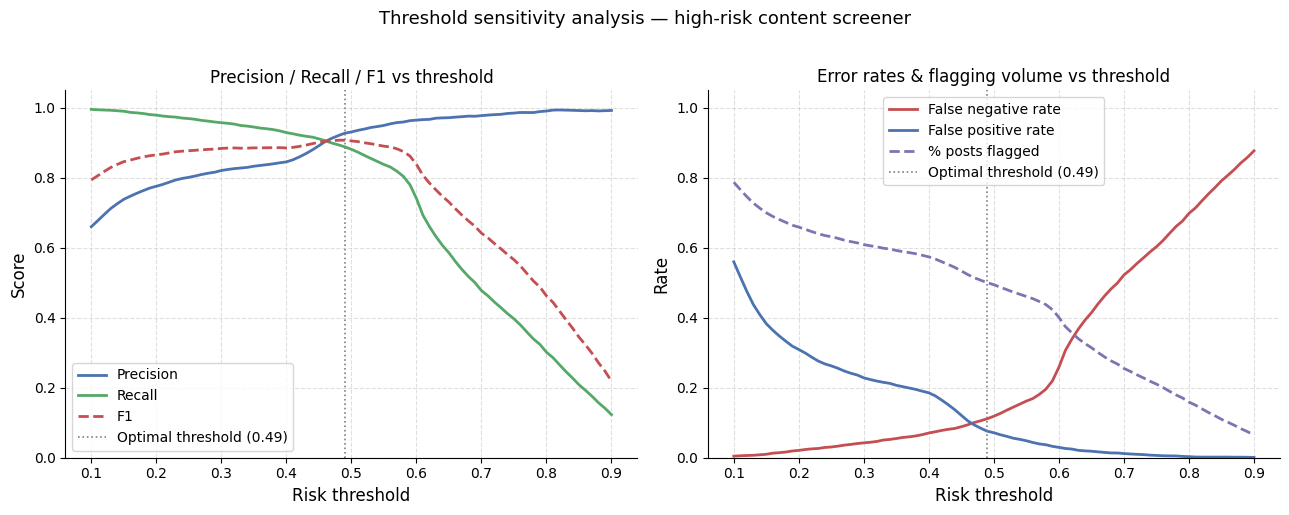

In [ ]:
# Threshold selection (test sensitivity)
thresholds = np.arange(0.10, 0.91, 0.01)
rows = []
for t in thresholds:
    flagged   = (risk_score >= t).astype(int)
    tp = int(np.sum((flagged == 1) & (high_risk_true == 1)))
    fp = int(np.sum((flagged == 1) & (high_risk_true == 0)))
    fn = int(np.sum((flagged == 0) & (high_risk_true == 1)))
    tn = int(np.sum((flagged == 0) & (high_risk_true == 0)))
 
    prec  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec   = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fnr   = fn / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr   = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    f1    = (2 * prec * rec / (prec + rec)) if (prec + rec) > 0 else 0.0
    flagged_pct = flagged.mean()
 
    rows.append({
        "Threshold":        round(t, 2),
        "Precision":        round(prec, 4),
        "Recall":           round(rec, 4),
        "F1":               round(f1, 4),
        "FNR":              round(fnr, 4),
        "FPR":              round(fpr, 4),
        "% Flagged":        round(flagged_pct, 4),
    })
 
thresh_df = pd.DataFrame(rows)
 
# Summary table at different range of thresholds
display(thresh_df[thresh_df["Threshold"].isin(
    [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
)].reset_index(drop=True))
 
# Find optimal F1 threshold
best_row = thresh_df.loc[thresh_df["F1"].idxmax()]
print(f"\nOptimal threshold (max F1): {best_row['Threshold']:.2f}")
print(f"  Precision : {best_row['Precision']:.4f}")
print(f"  Recall    : {best_row['Recall']:.4f}")
print(f"  F1        : {best_row['F1']:.4f}")
print(f"  FNR       : {best_row['FNR']:.4f}  ← missed high-risk posts")
print(f"  FPR       : {best_row['FPR']:.4f}  ← false alarms")
print(f"  % Flagged : {best_row['% Flagged']*100:.1f}% of all posts")
 
# Plot formatting
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Left plot: Precision / Recall / F1 vs threshold
ax = axes[0]
ax.plot(thresh_df["Threshold"], thresh_df["Precision"], label="Precision",
        linewidth=2, color="#4C72B0")
ax.plot(thresh_df["Threshold"], thresh_df["Recall"],    label="Recall",
        linewidth=2, color="#55A868")
ax.plot(thresh_df["Threshold"], thresh_df["F1"],        label="F1",
        linewidth=2, color="#C44E52", linestyle="--")
ax.axvline(best_row["Threshold"], color="gray", linestyle=":", linewidth=1.2,
           label=f"Optimal threshold ({best_row['Threshold']:.2f})")
ax.set_xlabel("Risk threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Precision / Recall / F1 vs threshold", fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(linestyle="--", alpha=0.4)
sns.despine(ax=ax)
 
# Right plot: FNR / FPR / % Flagged vs threshold
ax2 = axes[1]
ax2.plot(thresh_df["Threshold"], thresh_df["FNR"],
         label="False negative rate", linewidth=2, color="#C44E52")
ax2.plot(thresh_df["Threshold"], thresh_df["FPR"],
         label="False positive rate", linewidth=2, color="#4C72B0")
ax2.plot(thresh_df["Threshold"], thresh_df["% Flagged"],
         label="% posts flagged",    linewidth=2, color="#8172B2", linestyle="--")
ax2.axvline(best_row["Threshold"], color="gray", linestyle=":", linewidth=1.2,
            label=f"Optimal threshold ({best_row['Threshold']:.2f})")
ax2.set_xlabel("Risk threshold", fontsize=12)
ax2.set_ylabel("Rate", fontsize=12)
ax2.set_title("Error rates & flagging volume vs threshold", fontsize=12)
ax2.legend(fontsize=10)
ax2.set_ylim(0, 1.05)
ax2.grid(linestyle="--", alpha=0.4)
sns.despine(ax=ax2)
 
plt.suptitle("Threshold sensitivity analysis — high-risk content screener",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [71]:
# Threshold for flagging
risk_threshold = 0.49

# If risk score >= 0.50, then flag = 1 (passed onto human moderators to review), flag = 0 otherwise
high_risk_flag = (risk_score >= risk_threshold).astype(int)

print("Number flagged for review:", high_risk_flag.sum())
print("Proportion flagged:", high_risk_flag.mean())

Number flagged for review: 4118
Proportion flagged: 0.5000607164541591


In [72]:
# Metrics evaluate how well the model identifies high-risk posts

print("High-risk screening results")
print("Accuracy: ", accuracy_score(high_risk_true, high_risk_flag))
print("Precision:", precision_score(high_risk_true, high_risk_flag, zero_division=0))
print("Recall:   ", recall_score(high_risk_true, high_risk_flag, zero_division=0))
print("F1-score: ", f1_score(high_risk_true, high_risk_flag, zero_division=0))

cm = confusion_matrix(high_risk_true, high_risk_flag)
print("\nConfusion matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0.0
false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0

print("\nFalse negative rate:", false_negative_rate)
print("False positive rate:", false_positive_rate)

High-risk screening results
Accuracy:  0.905525197328476
Precision: 0.9276347741622146
Recall:    0.8883720930232558
F1-score:  0.9075789973865527

Confusion matrix:
[[3637  298]
 [ 480 3820]]

False negative rate: 0.11162790697674418
False positive rate: 0.07573062261753494


In [73]:
# Summary table

screening_summary = pd.DataFrame({
    "Metric": [
        "Threshold",
        "Proportion Flagged",
        "High-Risk Precision",
        "High-Risk Recall",
        "High-Risk F1",
        "False Negative Rate",
        "False Positive Rate"
    ],
    "Value": [
        risk_threshold,
        high_risk_flag.mean(),
        precision_score(high_risk_true, high_risk_flag, zero_division=0),
        recall_score(high_risk_true, high_risk_flag, zero_division=0),
        f1_score(high_risk_true, high_risk_flag, zero_division=0),
        false_negative_rate,
        false_positive_rate
    ]
})

screening_summary

,Metric,Value
0,Threshold,0.490000
1,Proportion Flagged,0.500061
2,High-Risk Precision,0.927635
3,High-Risk Recall,0.888372
4,High-Risk F1,0.907579
5,False Negative Rate,0.111628
6,False Positive Rate,0.075731


In [74]:
#  Some Examples: actual posts flagged as high risk

val_results = pd.DataFrame({
    "text": X_val_text.reset_index(drop=True) if hasattr(X_val_text, "reset_index") else pd.Series(X_val_text),
    "true_label": y_val_labels,
    "predicted_label": label_encoder.inverse_transform(hybrid_val_pred),
    "risk_score": risk_score,
    "flagged_for_review": high_risk_flag
})

# Sort by highest risk score
flagged_examples = val_results[val_results["flagged_for_review"] == 1] \
    .sort_values("risk_score", ascending=False)

flagged_examples.head(10)

,text,true_label,predicted_label,risk_score,flagged_for_review
7861,i just lost a friend of my suicidal thoughts a...,Suicidal,Suicidal,0.992881,1
5484,i have been suicidal for the past 3 weeks i do...,Depression,Suicidal,0.990943,1
1579,my only friend left me out of no where he told...,Suicidal,Suicidal,0.989181,1
3090,i do not know what to really type here i guess...,Suicidal,Suicidal,0.989134,1
374,i am really scared i am going to do something ...,Suicidal,Suicidal,0.987882,1
5619,i have no access to any tall buildings guns an...,Suicidal,Suicidal,0.984646,1
614,i am going to overdose properly this timefirst...,Suicidal,Suicidal,0.983559,1
6830,assisted suicide vs suicide vs outward harmnee...,Suicidal,Suicidal,0.982295,1
2907,as a religious person my religion is buddhism ...,Suicidal,Suicidal,0.981977,1
3759,i want to kill myself i am so fucking done,Suicidal,Suicidal,0.980874,1


In [75]:
# False negatives: Missed high-risk posts (actually high riks, but not flagged)

missed_high_risk = val_results[
    (np.isin(val_results["true_label"], ["Suicidal", "Depression"])) &
    (val_results["flagged_for_review"] == 0)
].sort_values("risk_score", ascending=True)

print("Number of missed high-risk posts:", len(missed_high_risk))
missed_high_risk.head(10)

Number of missed high-risk posts: 480


,text,true_label,predicted_label,risk_score,flagged_for_review
7908,ahh,Depression,Normal,0.023986,0
3642,it is sickening what is sickening is we elect ...,Suicidal,Normal,0.041417,0
7654,same story different girl,Depression,Normal,0.049149,0
1970,my heart is so crushed,Suicidal,Normal,0.063705,0
3515,tfw it is 5pm and you still have not got out o...,Depression,Normal,0.066898,0
4600,aahahhaahahahaa hee hee aahaahhahahahahhahahah...,Suicidal,Normal,0.068231,0
4471,can you? did not sink so you can ban me once c...,Depression,Normal,0.074883,0
843,my wife on his will it says he is left all his...,Suicidal,Normal,0.076153,0
4874,lool see you all on the other sidee bye!!,Suicidal,Normal,0.078278,0
1460,tillsonburg ontario ok,Suicidal,Normal,0.083569,0
